# Parametric Problems

$$\def\RR{\mathbb{R}}
\def\NN{\mathbb{N}}
\def\ZZ{\mathbb{Z}}
\def\I{\mathbf{I}}
\def\0{\mathbf{0}}
\def\1{\mathbf{1}}
\def\q{\mathbf{q}}
\def\u{\mathbf{u}}
\def\z{\mathbf{z}}
\def\d{\mathbf{d}}
\def\f{\mathbf{f}}
\def\s{\mathbf{s}}
\def\Q{\mathbf{Q}}
\def\U{\mathbf{U}}
\def\Z{\mathbf{Z}}
\def\Op{\mathbf{f}}
\def\Ophat{\hat{\mathbf{f}}}
\def\c{\mathbf{c}}
\def\A{\mathbf{A}}
\def\H{\mathbf{H}}
\def\G{\mathbf{G}}
\def\B{\mathbf{B}}
\def\N{\mathbf{N}}
\def\v{\mathbf{v}}
\def\w{\mathbf{w}}
\def\V{\mathbf{V}}
\def\W{\mathbf{W}}
\def\Vr{\mathbf{V}_{\!r}}
\def\Wr{\mathbf{W}_{\!r}}
\def\qhat{\hat{\mathbf{q}}}
\def\zhat{\hat{\mathbf{z}}}
\def\fhat{\hat{\mathbf{f}}}
\def\Qhat{\hat{\mathbf{Q}}}
\def\Zhat{\hat{\mathbf{Z}}}
\def\chat{\hat{\mathbf{c}}}
\def\Ahat{\hat{\mathbf{A}}}
\def\Hhat{\hat{\mathbf{H}}}
\def\Ghat{\hat{\mathbf{G}}}
\def\Bhat{\hat{\mathbf{B}}}
\def\Nhat{\hat{\mathbf{N}}}
\def\D{\mathbf{D}}
\def\ohat{\hat{\mathbf{o}}}
\def\Ohat{\hat{\mathbf{O}}}
\def\bfmu{\boldsymbol{\mu}}
\def\bfGamma{\boldsymbol{\Gamma}}
\def\bfPhi{\boldsymbol{\Phi}}
\def\bfSigma{\boldsymbol{\Sigma}}
\def\bfPsi{\boldsymbol{\Psi}}
\def\bfLambda{\boldsymbol{\Lambda}}
\def\bfxi{\boldsymbol{\xi}}
\def\trp{{^{\mathsf{T}}}}
\def\ddt{\frac{\textrm{d}}{\textrm{d}t}}
\def\ddqhat{\frac{\partial}{\partial\qhat}}
\def\mean{\operatorname{mean}}
\def\std{\operatorname{std}}
\def\argmin{\operatorname{argmin}}$$

Many systems depend on independent parameters that describe material properties or other physical characteristics of the phenomenon being modeled.
In such cases, the operators of a reduced-order model (ROM) should be designed to vary with the system parameters. This tutorial demonstrates how to construct and evaluate a parametric ROM through an elementary example.

## Problem Statement

We consider a problem with a single scalar system parameter $\mu > 0$.

:::{admonition} Governing Equations
:class: info

Let $\Omega = [0,L]\subset \RR$ be the spatial domain indicated by the variable $x$, and let $[0,T]\subset\RR$ be the time domain with variable $t$. We consider the one-dimensional heat equation with constant non-homogeneous Dirichlet boundary conditions,

$$
\begin{aligned}
    &\frac{\partial}{\partial t} q(x,t;\mu) = \mu\frac{\partial^2}{\partial x^2}q(x,t;\mu)
    & x &\in\Omega,\quad t\in[0,T],
    \\
    &q(0,t;\mu) = q(L,t;\mu) = 1
    & t &\in[0,T],
    \\
    &q(x,0;\mu) = \big(e^{\alpha(x - 1)} + e^{-\alpha x} - e^{-\alpha}\big)
    & x &\in \Omega,
\end{aligned}
$$

where the constant $\mu > 0$ is a thermal diffusivity parameter, $\alpha>0$ is constant, and $q(x,t;\mu)$ is the unknown state variable. This is a model for a one-dimensional rod conducting heat with a fixed initial heat profile. The temperature at the ends of the rod are fixed, but heat is allowed to diffuse through the rod and flow out at the ends of the domain.
:::

:::{admonition} Objective
:class: info

Construct a reduced-order model (ROM) which can be solved rapidly to produce approximate solutions $q(x, t; \mu)$ to the partial differential equation given above for various choices of the diffusivity parameter $\mu > 0$.
We will observe data for a few values of $\mu$, then use the ROM to predict the solution for the entire time domain $[0, T]$ and for new values of $\mu$. 
Hence, the ROM will be **predictive in the parameter** $\mu$.

<!-- over a limited time interval $t\in[0,T']$ with $T' < T$, -->
<!-- **predictive in time** and -->
:::

In [1]:
import h5py
import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt

import opinf

opinf.utils.mpl_config()

## Full-order Model Definition

We consider the parameter domain $\mathcal{P} = [.1,10]\subset\RR$.
A finite element or finite difference discretization leads to a system of differential equations,

$$
\begin{aligned}
    \ddt\q(t;\mu)
    = \c(\mu) + \A(\mu)\q(t;\mu),
    \qquad
    \q(0) = \q_0,
\end{aligned}
$$ (eq_parametric_fom)

where $\q:\RR\times\mathcal{P}\to\RR^n,$ $\c:\mathcal{P}\to\RR^n,$ and $\A:\mathcal{P}\to\RR^{n\times n}.$
This is the full-order model (FOM).
The constant term $\c(\mu)$ arises due to the nonzero boundary conditions.
In this case, the parametric dependence on $\mu$ is linear: there are $\c^{(0)}\in\RR^{n}$ and $\A^{(0)}\in\RR^{n\times n}$ such that $\c(\mu) = \mu\c^{(0)}$ and $\A(\mu) = \mu\A^{(0)}.$

:::{dropdown} Discretization details

We take an equidistant grid $\{x_i\}_{i=0}^{n+1} \subset \Omega$,

\begin{align*}
    0 &= x_0 < x_1 < \cdots < x_n < x_{n+1} = L
    &
    &\text{and}
    &
    \delta x &= \frac{L}{n+1} = x_{i+1} - x_{i},\quad i=1,\ldots,n-1.
\end{align*}

The boundary conditions prescribe $q(x_0,t;\mu) = q(x_{n+1},t;\mu) = 1$.
Our goal is to compute $q(x,t)$ at the interior spatial points $x_{1},x_{2},\ldots,x_{n}$ for various $t\in[0,T]$, so we consider the state vector $\q(t;\mu) = [~q(x_{1}, t;\mu)~\cdots~q(x_{n}, t;\mu)~]\trp\in\RR^n$ and derive a system governing the evolution of $\q(t;\mu)$ in time.

Approximating the spatial derivative with a central finite difference approximation,

$$
    \frac{\partial^2}{\partial x^2}q(x,t)
    \approx \frac{q(x-\delta x,t) - 2q(x,t) + q(x+\delta x,t)}{(\delta x)^2},
$$

and using the boundary conditions $q(0,t;\mu) = q(L,t;\mu) = 1$, we arrive at the following matrices for the FOM.

$$
\begin{aligned}
    \c^{(0)} &= \frac{1}{(\delta x)^2}\left[\begin{array}{c}
        1 \\ 0 \\ \vdots \\ 0 \\ 1
    \end{array}\right]\in\RR^{n},
    &
    \A^{(0)} &= \frac{1}{(\delta x)^2}\left[\begin{array}{ccccc}
        -2 & 1 & & & \\
        1 & -2 & 1 & & \\
        & \ddots & \ddots & \ddots & \\
        & & 1 & -2 & 1 \\
        & & & 1 & -2 \\
    \end{array}\right] \in\RR^{n\times n}.
\end{aligned}
$$
:::

## Training Data

:::{button-link} https://github.com/operator-inference/opinf/raw/refs/heads/data/parametric_data.h5
:color: success
:outline:
To download the data, click here.


For this demo, we load pre-generated data. Download it using the button above, and then place it in the same directory as this tutorial.
The data was generated with $L = 1$, $T = 1$, $\alpha = 100$, and $n = 2^{10} - 1 = 1023$ spatial degrees of freedom, and snapshots recorded every every $\delta t = 0.0025$ time units.
For each training parameter $\mu_i$, this results in $k = 401$ state snapshots, organized in snapshot matrices

$$
\begin{aligned}
    \Q_i = \left[\begin{array}{cccc}
        \q(t_0;\mu_i) & \q(t_1;\mu_i) & \cdots & \q(t_{k-1};\mu_i)
    \end{array}\right]
    \in\RR^{n\times k},
    \quad
    i = 0,\ldots, s-1.
\end{aligned}
$$


In [2]:
Qs = []
training_parameters = []

with h5py.File("parametric_data.h5", "r") as f:
    num_mu_values = f["train"].attrs["num_mu_values"]
    t_all = f["t"][:]
    x_all = f["x"][:]
    q0 = f["q_0"][:]
    for idx in range(1, num_mu_values+1):
        Qs.append(f["train"][f"Step {idx}"][:])
        training_parameters.append(f["train"][f"Step {idx}"].attrs["mu"])

print(f"\nSpatial domain:\t\t{x_all.shape=}")
print(f"\nFull time domain:\t{t_all.shape=}")
print(f"\nTraining snapshots:\t{Qs[0].shape=}")


Spatial domain:		x_all.shape=(1023,)

Full time domain:	t_all.shape=(401,)

Training snapshots:	Qs[0].shape=(1023, 401)


In [3]:
def plot_data_space(Z, title, ax=None):
    """Plot state data over space at multiple instances in time."""
    if ax is None:
        _, ax = plt.subplots(1, 1)

    # Plot a few snapshots over the spatial domain.
    sample_columns = [0] + [2**d for d in range(10)]
    color = iter(plt.cm.viridis_r(np.linspace(0.05, 1, len(sample_columns))))
    while sample_columns[-1] > Z.shape[1] - 1:
        sample_columns = sample_columns[:-1]
    for j in sample_columns:
        q_all = np.concatenate([[0.5], Z[1:-1, j], [1]])
        c = next(color)
        ax.plot(x_all, q_all, lw=1, color=c, label=rf"$q(x,t_{{{j}}})$")

    ax.set_xlim(x_all[0], x_all[-1])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$q(x,t)$")
    ax.legend(loc=(1.05, 0.05))
    ax.set_title(title)


def plot_two_datasets(Z1, title1, Z2, title2):
    """Plot two datasets side by side."""
    _, [ax1, ax2] = plt.subplots(1, 2)
    plot_data_space(Z1, title1, ax1)
    plot_data_space(Z2, title2, ax2)
    ax1.legend([])

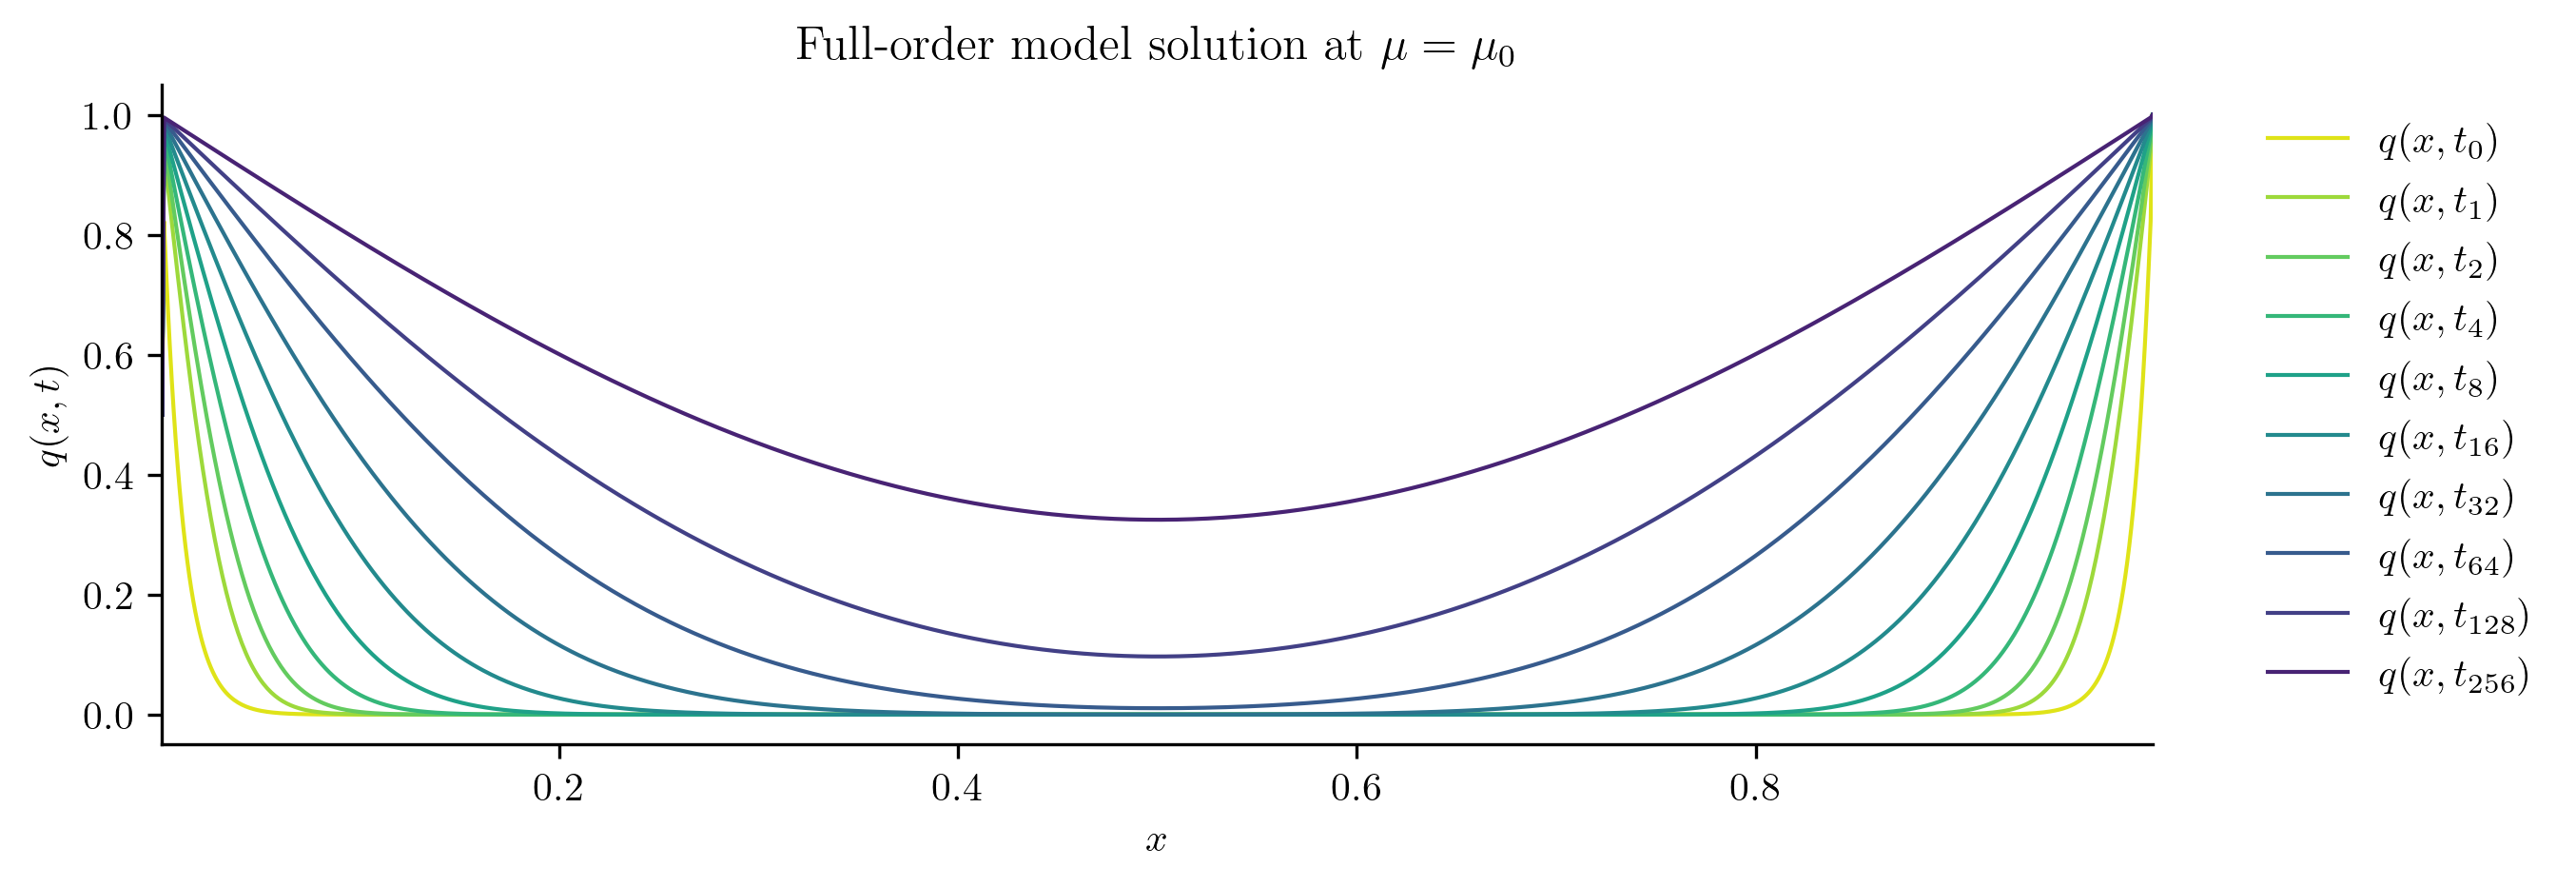

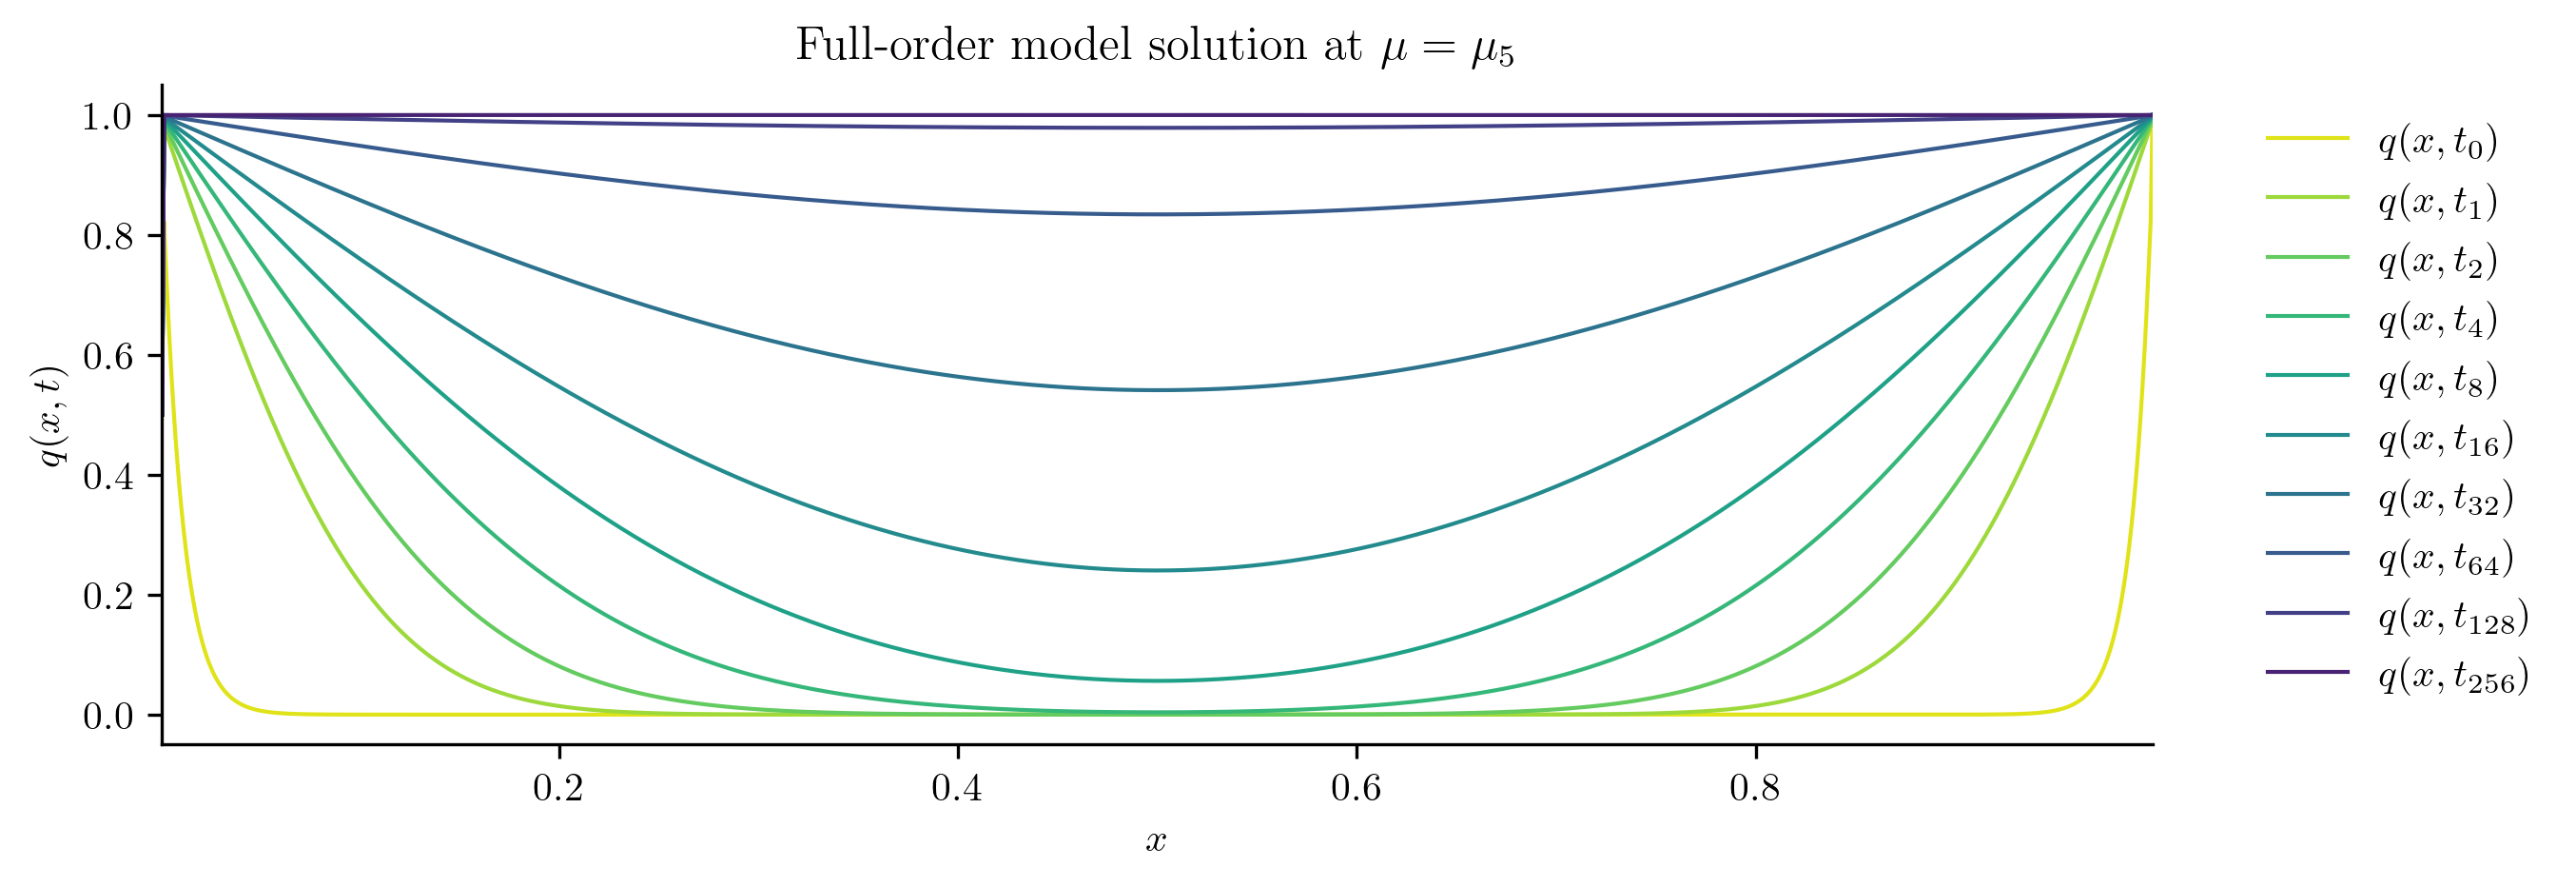

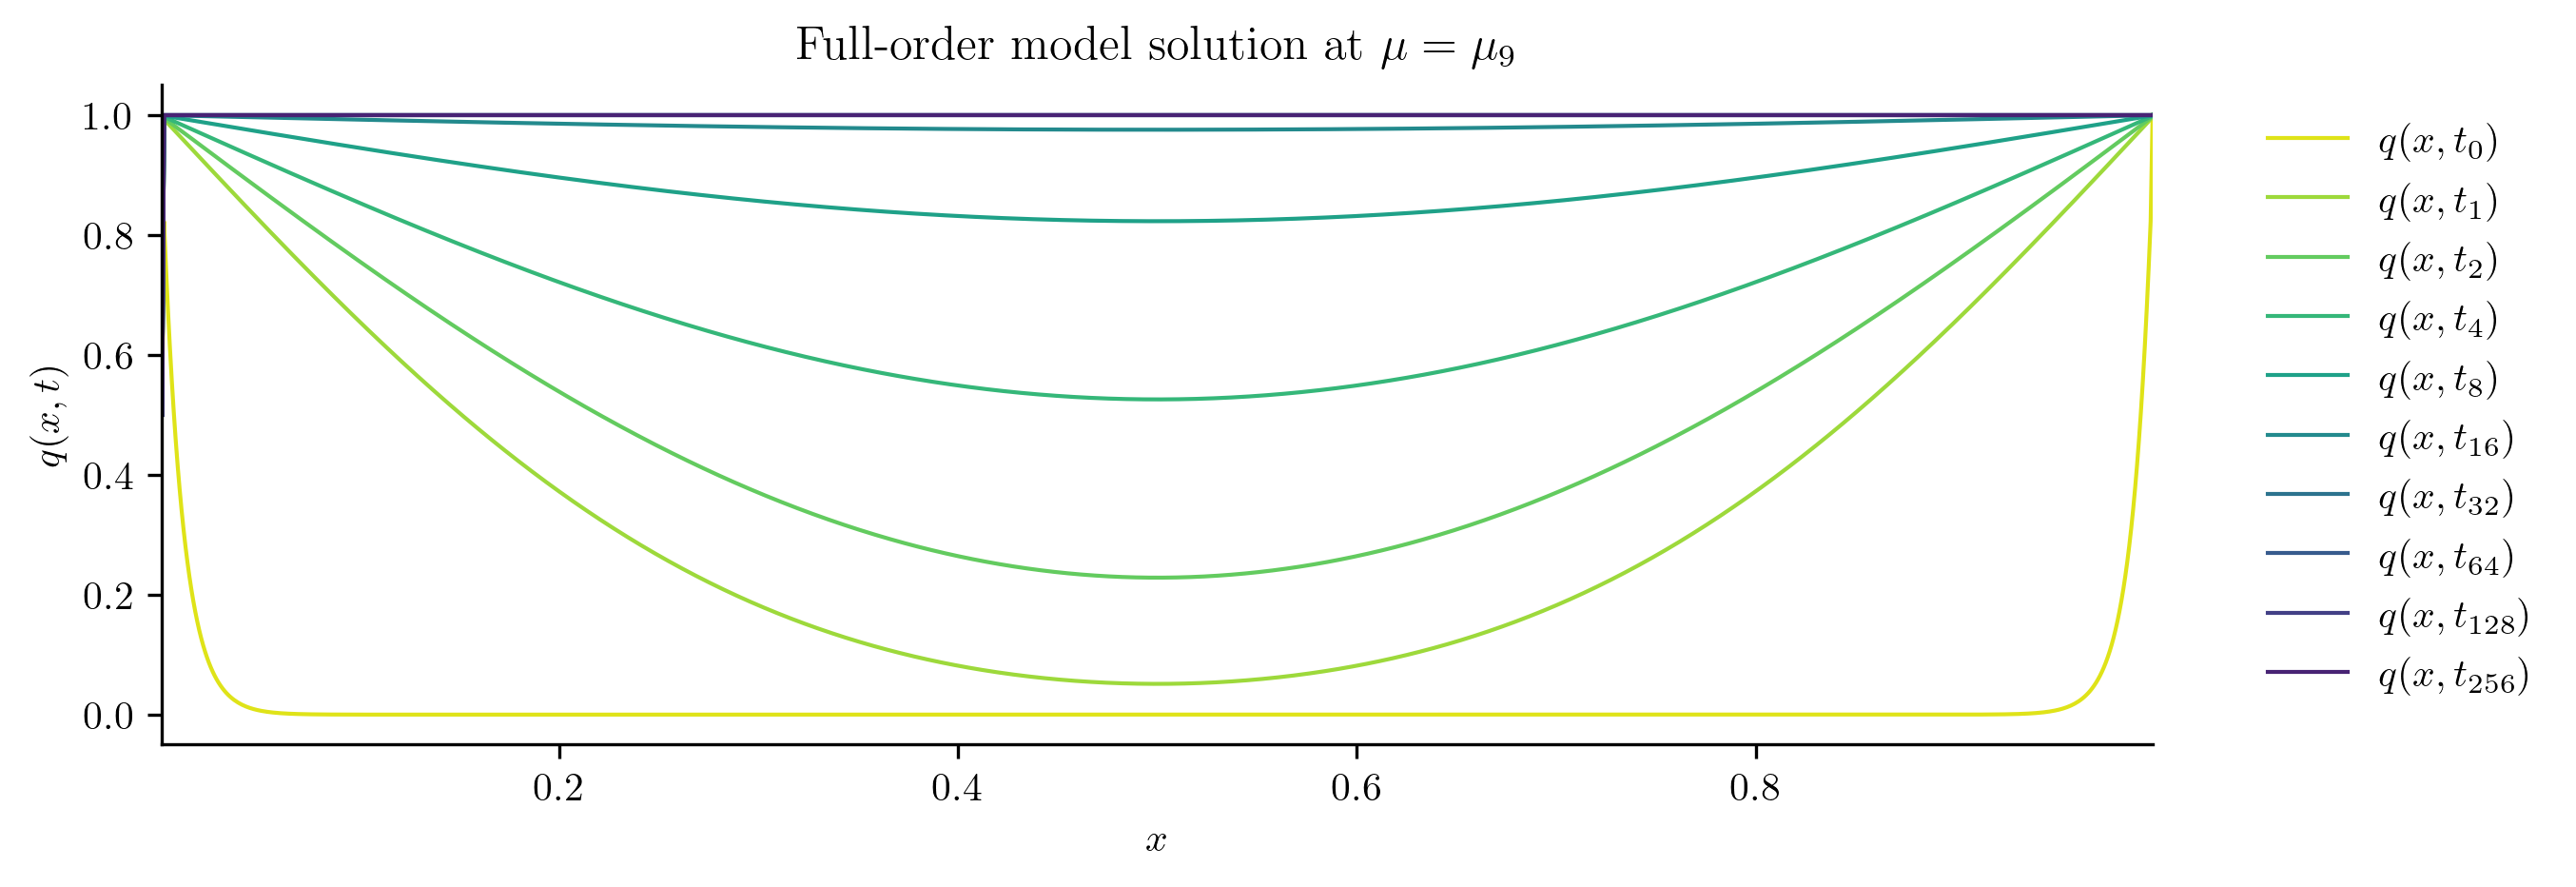

In [4]:
for i in [0, num_mu_values // 2, num_mu_values - 1]:
    plot_data_space(Qs[i], rf"Full-order model solution at $\mu = \mu_{i}$")

## Reduced-order Model Construction

Now that we have parameter and snapshot data, we instantiate a {class}`opinf.roms.ParametricROM` and pass the training parameter values and the corresponding state snapshots to the `fit()` method.

We will use a {class}`opinf.basis.PODBasis` to reduce the dimension of the snapshot training data, which approximates the discretized state vector as $\q(t;\mu) \approx \Vr\qhat(t;\mu)$ for some $\Vr\in\RR^{n\times r}$ with orthonormal columns and $\qhat(t)\in\RR^{r}$, with and $r\ll n$.
Based on the FOM {eq}`eq_parametric_fom`, we specify a ROM with the following structure:

$$
\begin{aligned}
    \ddt\qhat(t;\mu)
    &= \chat(\mu) + \Ahat(\mu)\qhat(t;\mu)
    = \mu\chat^{(0)} + \mu\Ahat^{(0)}\qhat(t;\mu),
\end{aligned}
$$

where $\chat^{(0)}\in\RR^{r}$ and $\Ahat^{(0)}\in\RR^{r\times r}.$
Data for the time derivative $\ddt\qhat(t)$ are estimated in this example with sixth-order finite differences using {class}`opinf.ddt.UniformFiniteDifferencer`.
The underlying least-squares problem to determine $\chat^{(0)}$ and $\Ahat^{(0)}$ is given by

$$
\begin{aligned}
    \min_{\Ahat,\Bhat}
    \sum_{i=0}^{s-1}\sum_{j=0}^{k-1}\left\|
        \mu_{i}\chat^{(0)} + \mu_{i}\Ahat^{(0)}\qhat_{i,j} - \dot{\qhat}_{i,j}
    \right\|_{2}^{2},
\end{aligned}
$$

where $\qhat_{i,j} = \qhat(t_j;\mu_i)\in\RR^{r}$ are the state snapshots and $\dot{\qhat}_{i,j} \approx \ddt\qhat(t;\mu_{i})|_{t=t_j}\in\RR^{r}$ are the estimated time derivatives.

:::{dropdown} Preserving Parametric Structure

An OpInf ROM should have the same structure as an intrusive Galerkin ROM.
The Galerkin ROM for {eq}`eq_parametric_fom` is derived by substituting in the approximation $\q(t;\mu)\approx\Vr\qhat(t;\mu)$, yielding

$$
\begin{aligned}
    \ddt\Vr\qhat(t;\mu)
    = \c(\mu) + \A(\mu)\Vr\qhat(t;\mu)
    \qquad
    \Vr\qhat(0) = \q_0.
\end{aligned}
$$

Next, left multiply by $\Vr\trp$ and use the fact that $\Vr\trp\Vr = \I$ to get the following:

$$
\begin{aligned}
    \ddt\qhat(t;\mu)
    = \tilde{\c} + \tilde{\A}(\mu)\qhat(t;\mu)
    \qquad
    \qhat(0) = \Vr\trp\q_0,
\end{aligned}
$$

where $\tilde{\c}(\mu) = \Vr\trp\c(\mu)\in\RR^{r}$ and $\tilde{\A}(\mu) = \Vr\trp\A(\mu)\Vr \in \RR^{r\times r}.$
Finally, using the formulae $\c(\mu) = \mu\c^{(0)}$ and $\A(\mu) = \mu\A^{(0)}$, we can further simplify to

$$
\begin{aligned}
    \tilde{\c}(\mu)
    &= \Vr\trp\c(\mu)
    = \mu\Vr\trp\c^{(0)}
    \\
    \tilde{\A}(\mu)
    &= \Vr\trp\A(\mu)\Vr
    = \mu\Vr\trp\A^{(0)}\Vr.
\end{aligned}
$$

:::

:::{admonition} Interpolatory and Affine Parameterizations
:class: tip

In this problem, the dependence on $\mu$ in the ROM operators $\chat(\mu)$ and $\Ahat(\mu)$ is known because the structure of the FOM is preserved by linear projection (see [affine operators](sec-operators-affine)).
If the dependence on $\mu$ is not known a-priori or cannot be written in an affine form, [interpolatory operators](sec-operators-interpolated) sometimes provide a feasible alternative.
:::

In [5]:
rom = opinf.ParametricROM(
    basis=opinf.basis.PODBasis(projection_error=1e-6),
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t_all, "ord6"),
    model=opinf.models.ParametricContinuousModel(
        operators=[
            opinf.operators.AffineConstantOperator(1),
            opinf.operators.AffineLinearOperator(1),
        ],
        solver=opinf.lstsq.L2Solver(1e-6),
    ),
).fit(training_parameters, Qs)

## Reduced-order Model Evaluation

We start by checking comparing the solutions of the ROM at the training parameter values to the training snapshots.

Reduced-order solve...done in 0.15 s.


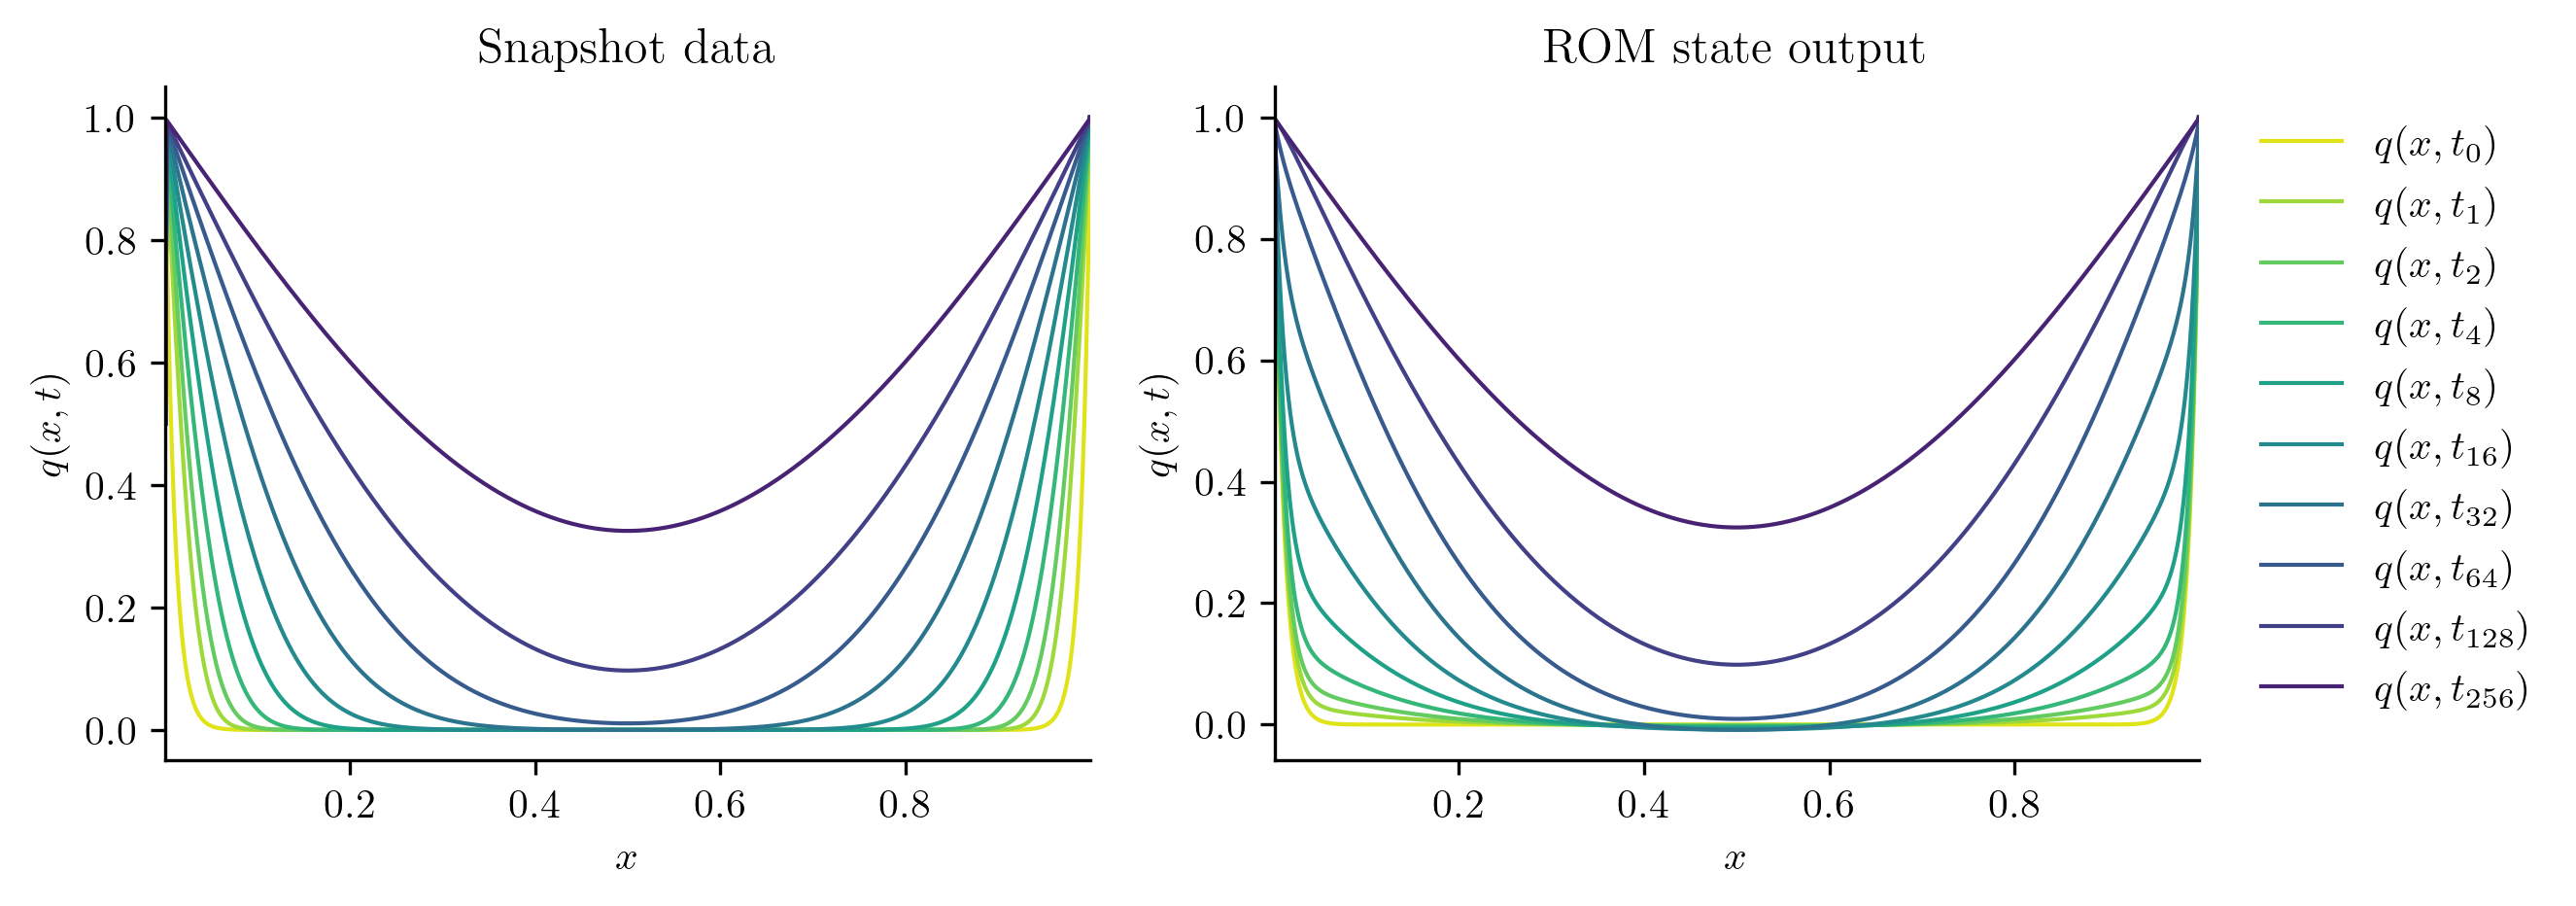

Reduced-order solve...done in 0.03 s.


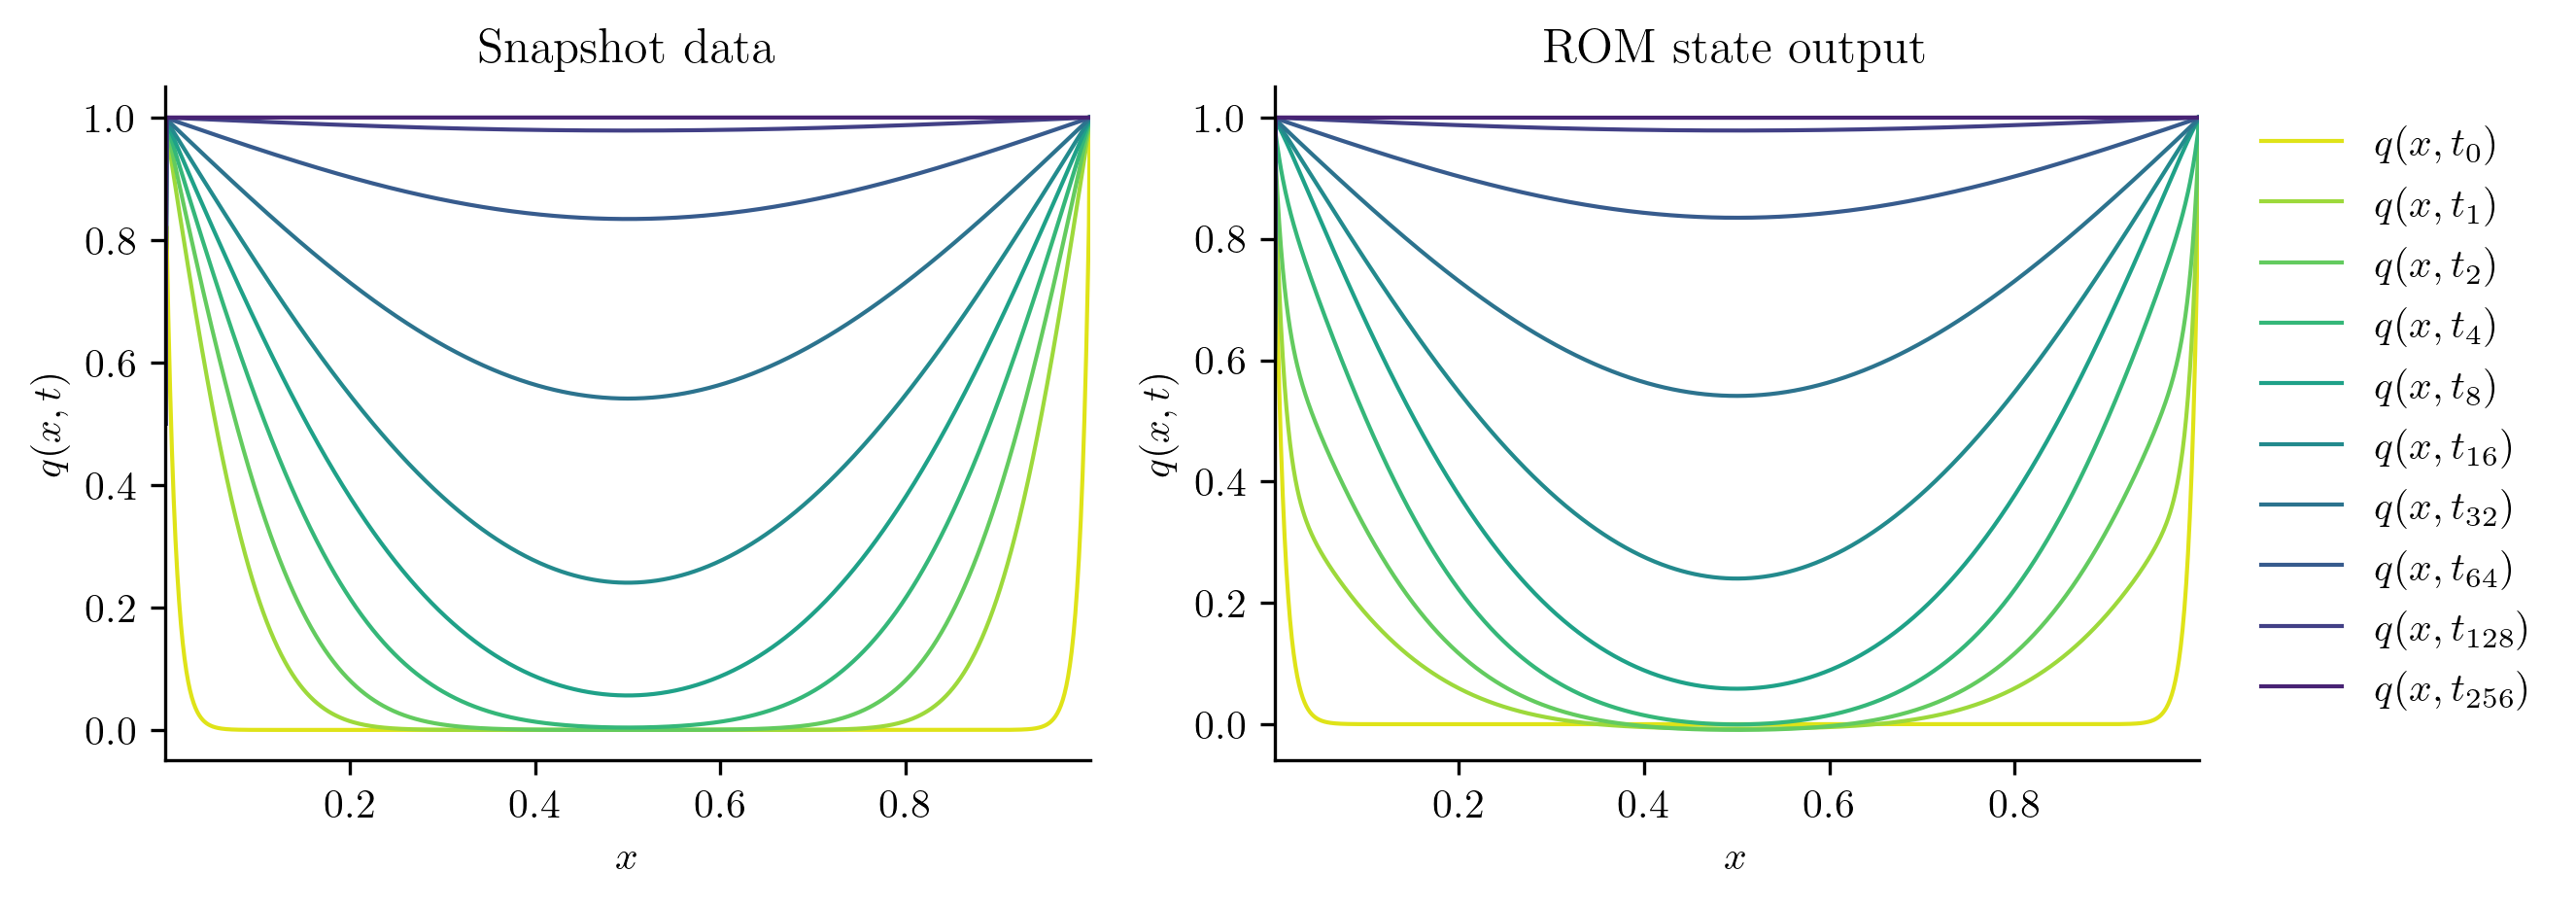

Reduced-order solve...done in 0.04 s.


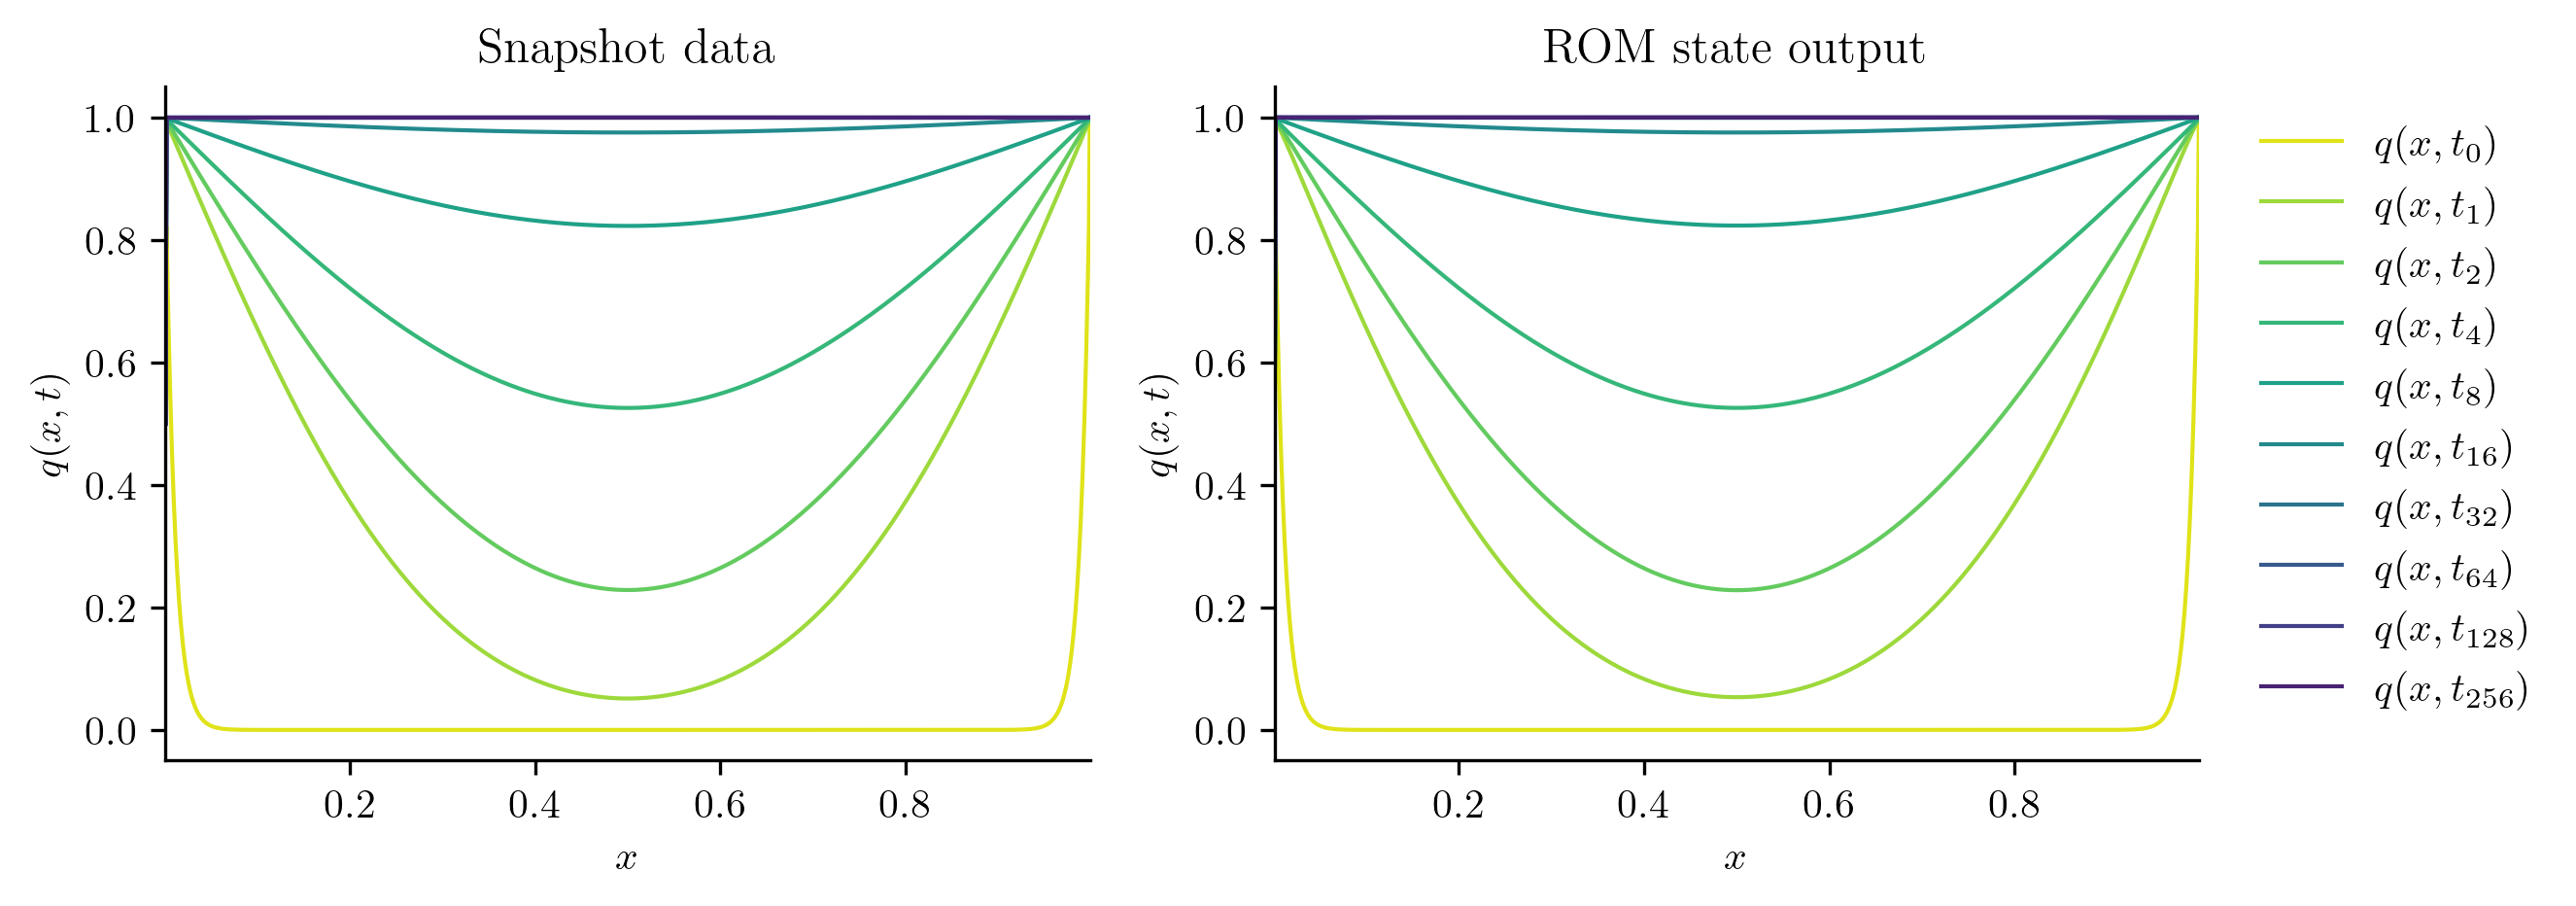

In [6]:
for i in [0, num_mu_values // 2, num_mu_values - 1]:
    with opinf.utils.TimedBlock("Reduced-order solve"):
        Q_ROM = rom.predict(training_parameters[i], q0, t_all, method="BDF")
    plot_two_datasets(Qs[i], "Snapshot data", Q_ROM, "ROM state output")
    plt.show()

Next, we solve ROM at new parameter values not included in the training set and compare it to previously collected snapshot data.

In [7]:
test_parameters = []
Qs_observed = []

with h5py.File("parametric_data.h5", "r") as f:
    num_test_parameters = f["test"].attrs["num_mu_values"]
    for idx in range(1, num_test_parameters+1):
        dset = f["test"][f"Step {idx}"]
        test_parameters.append(dset.attrs[f"mu"])
        Qs_observed.append(dset[:])

print(test_parameters)

[np.float64(0.1291549665014884), np.float64(0.21544346900318836), np.float64(0.3593813663804627), np.float64(0.599484250318941), np.float64(1.0), np.float64(1.6681005372000588), np.float64(2.782559402207124), np.float64(4.6415888336127775), np.float64(7.74263682681127)]


Reduced-order solve...done in 0.08 s.


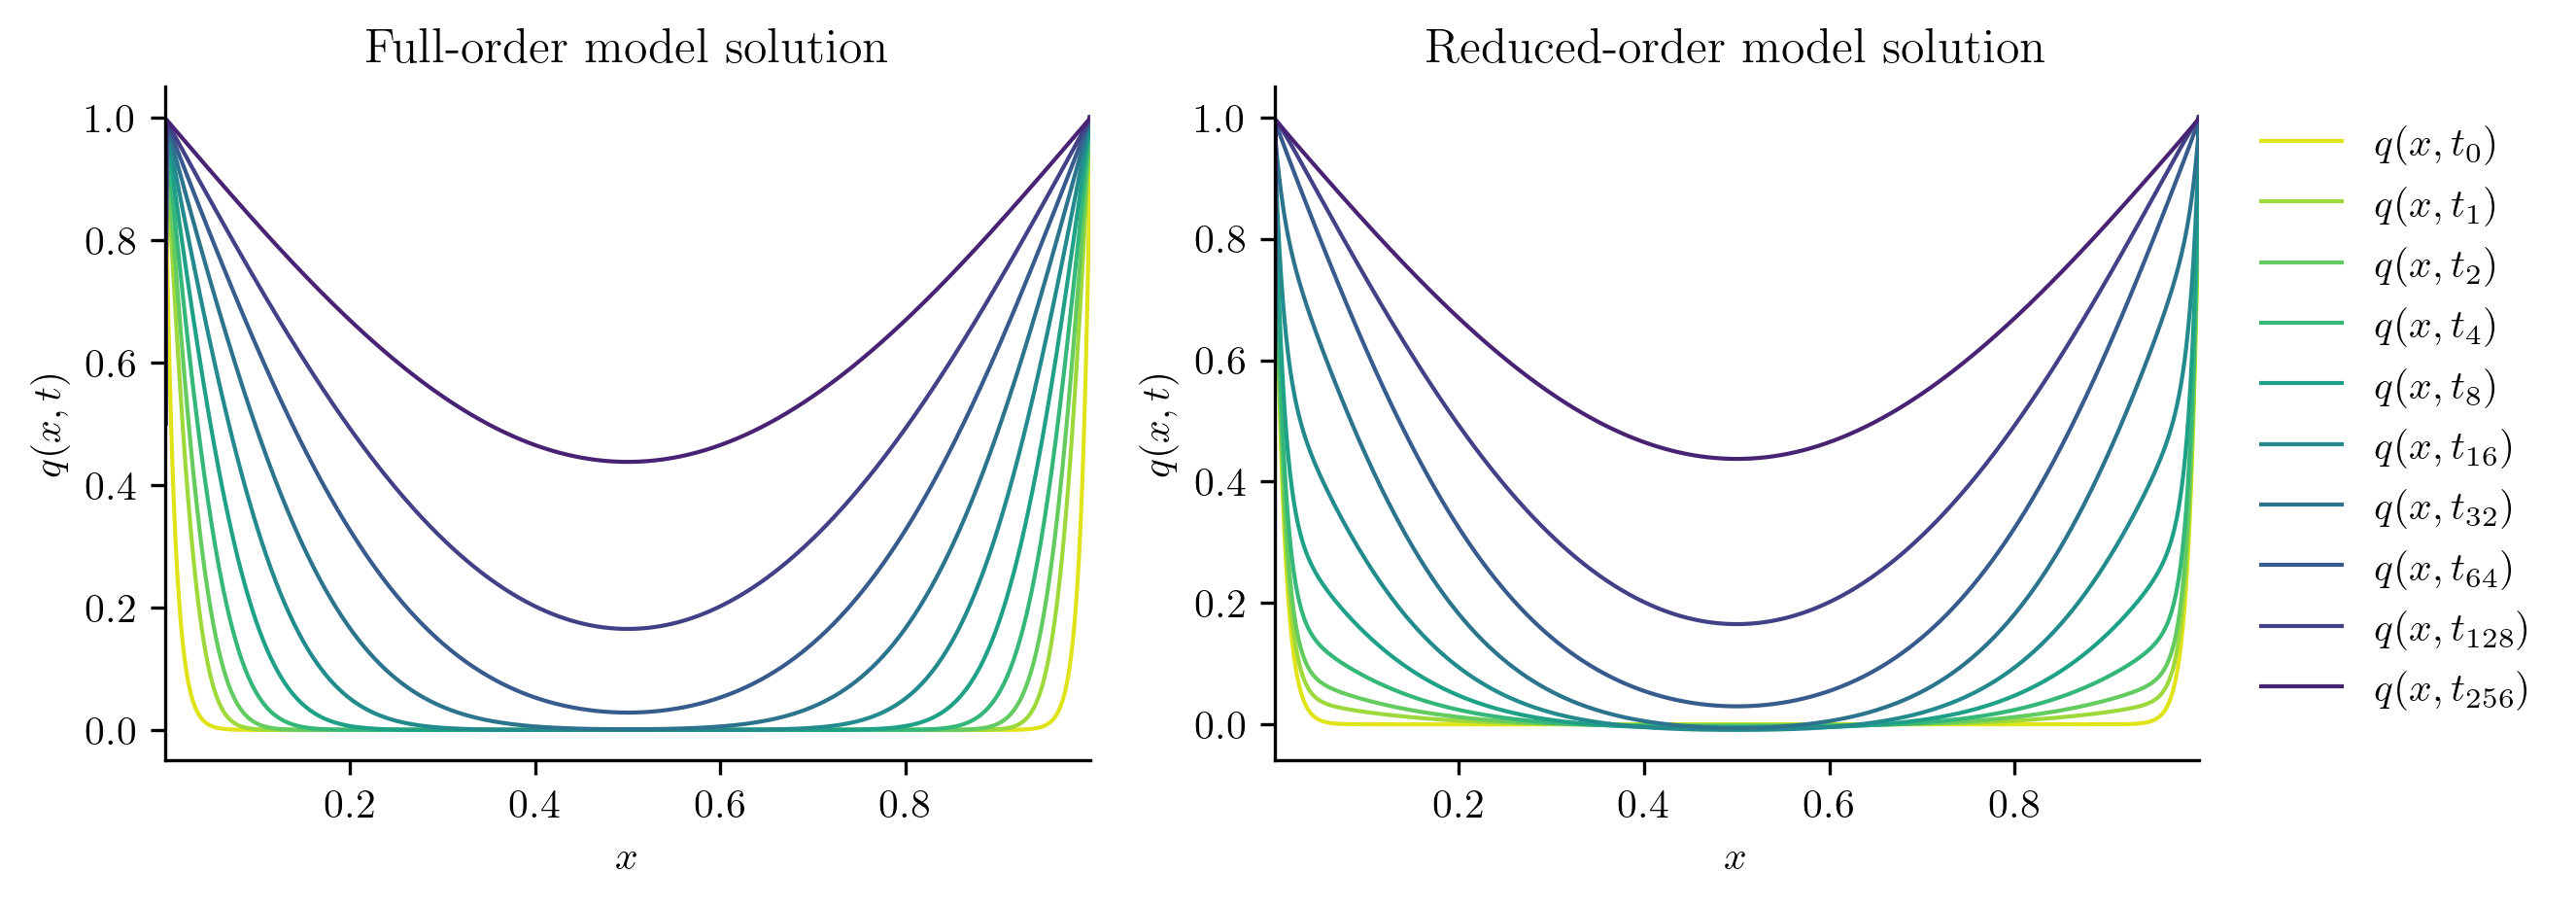

Reduced-order solve...done in 0.11 s.


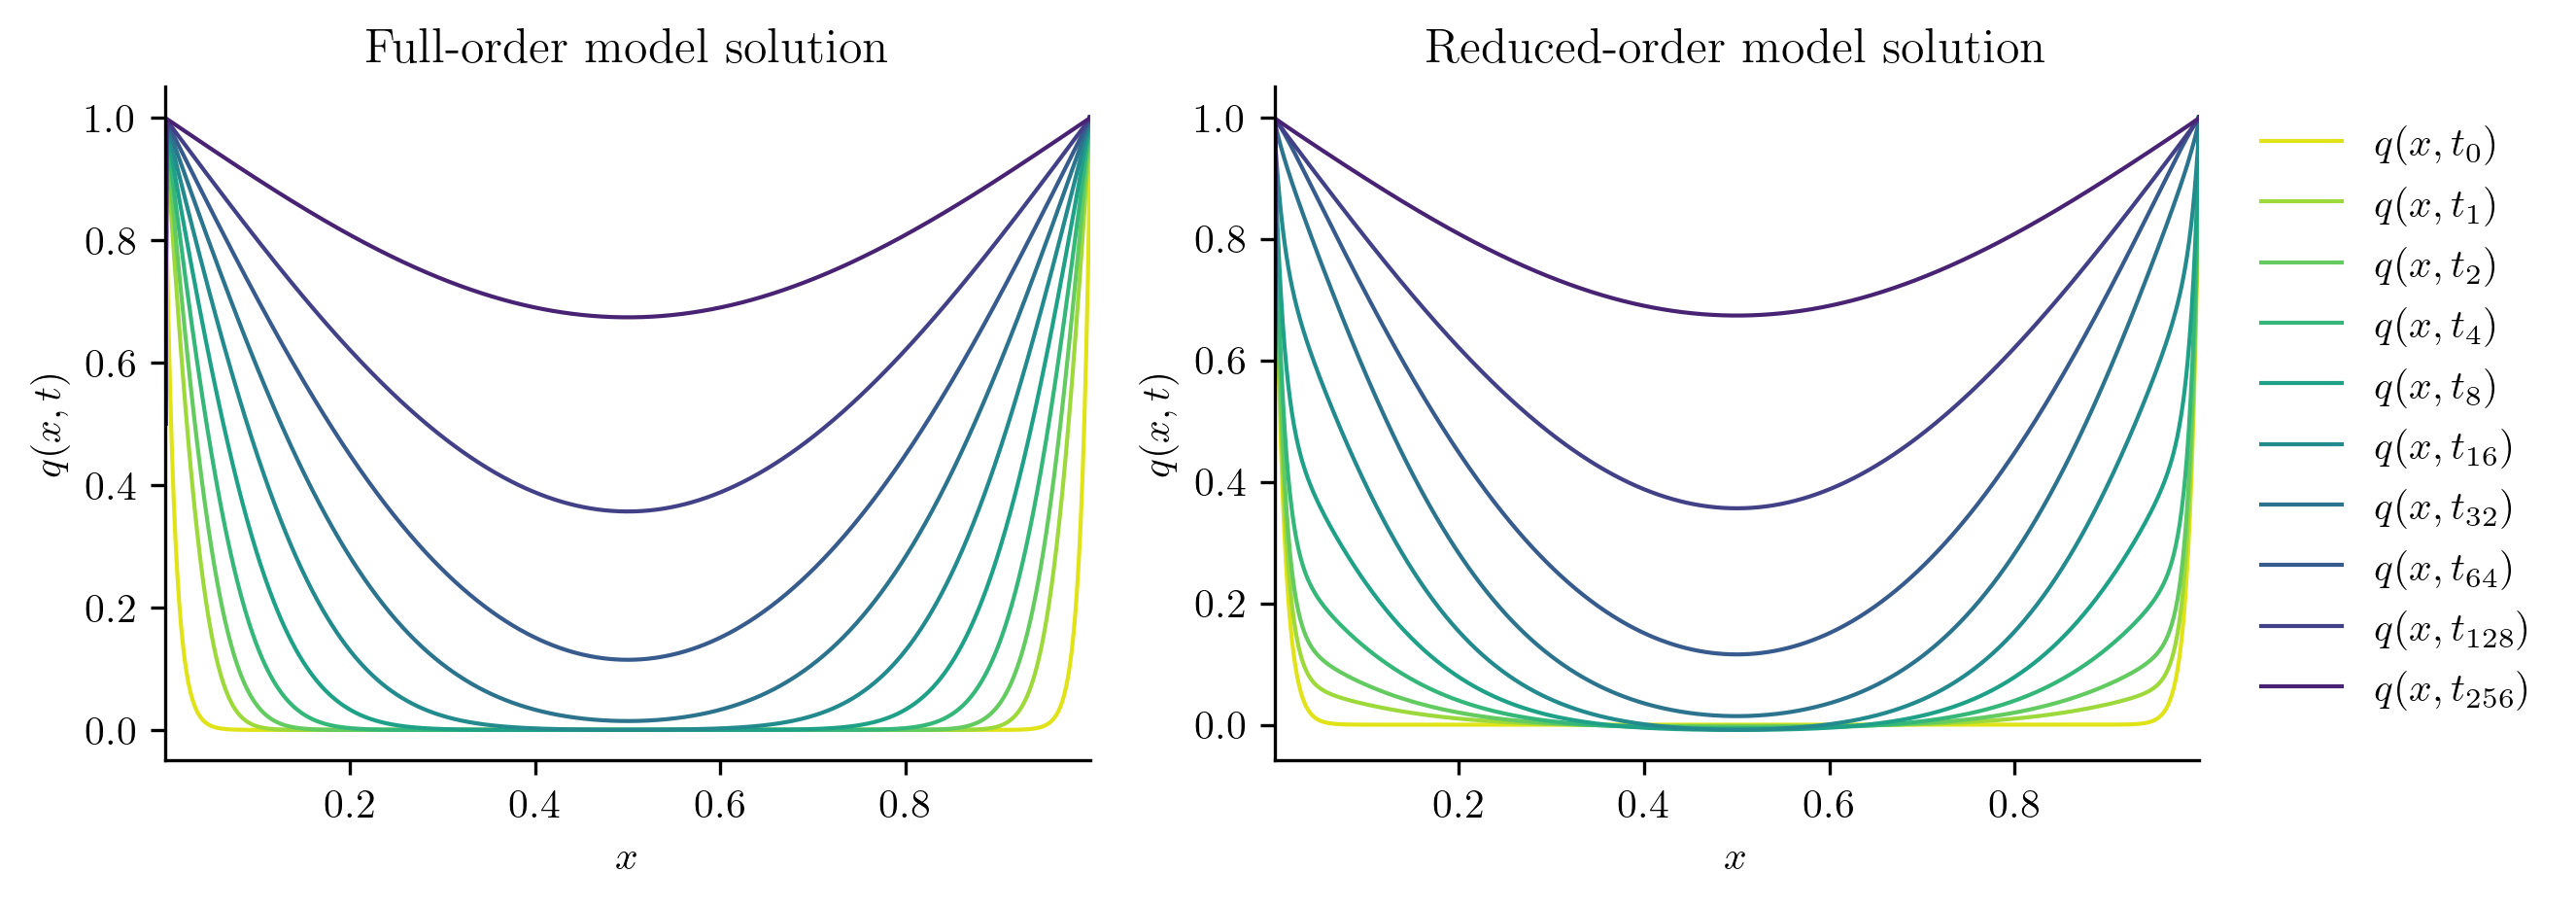

Reduced-order solve...done in 0.14 s.


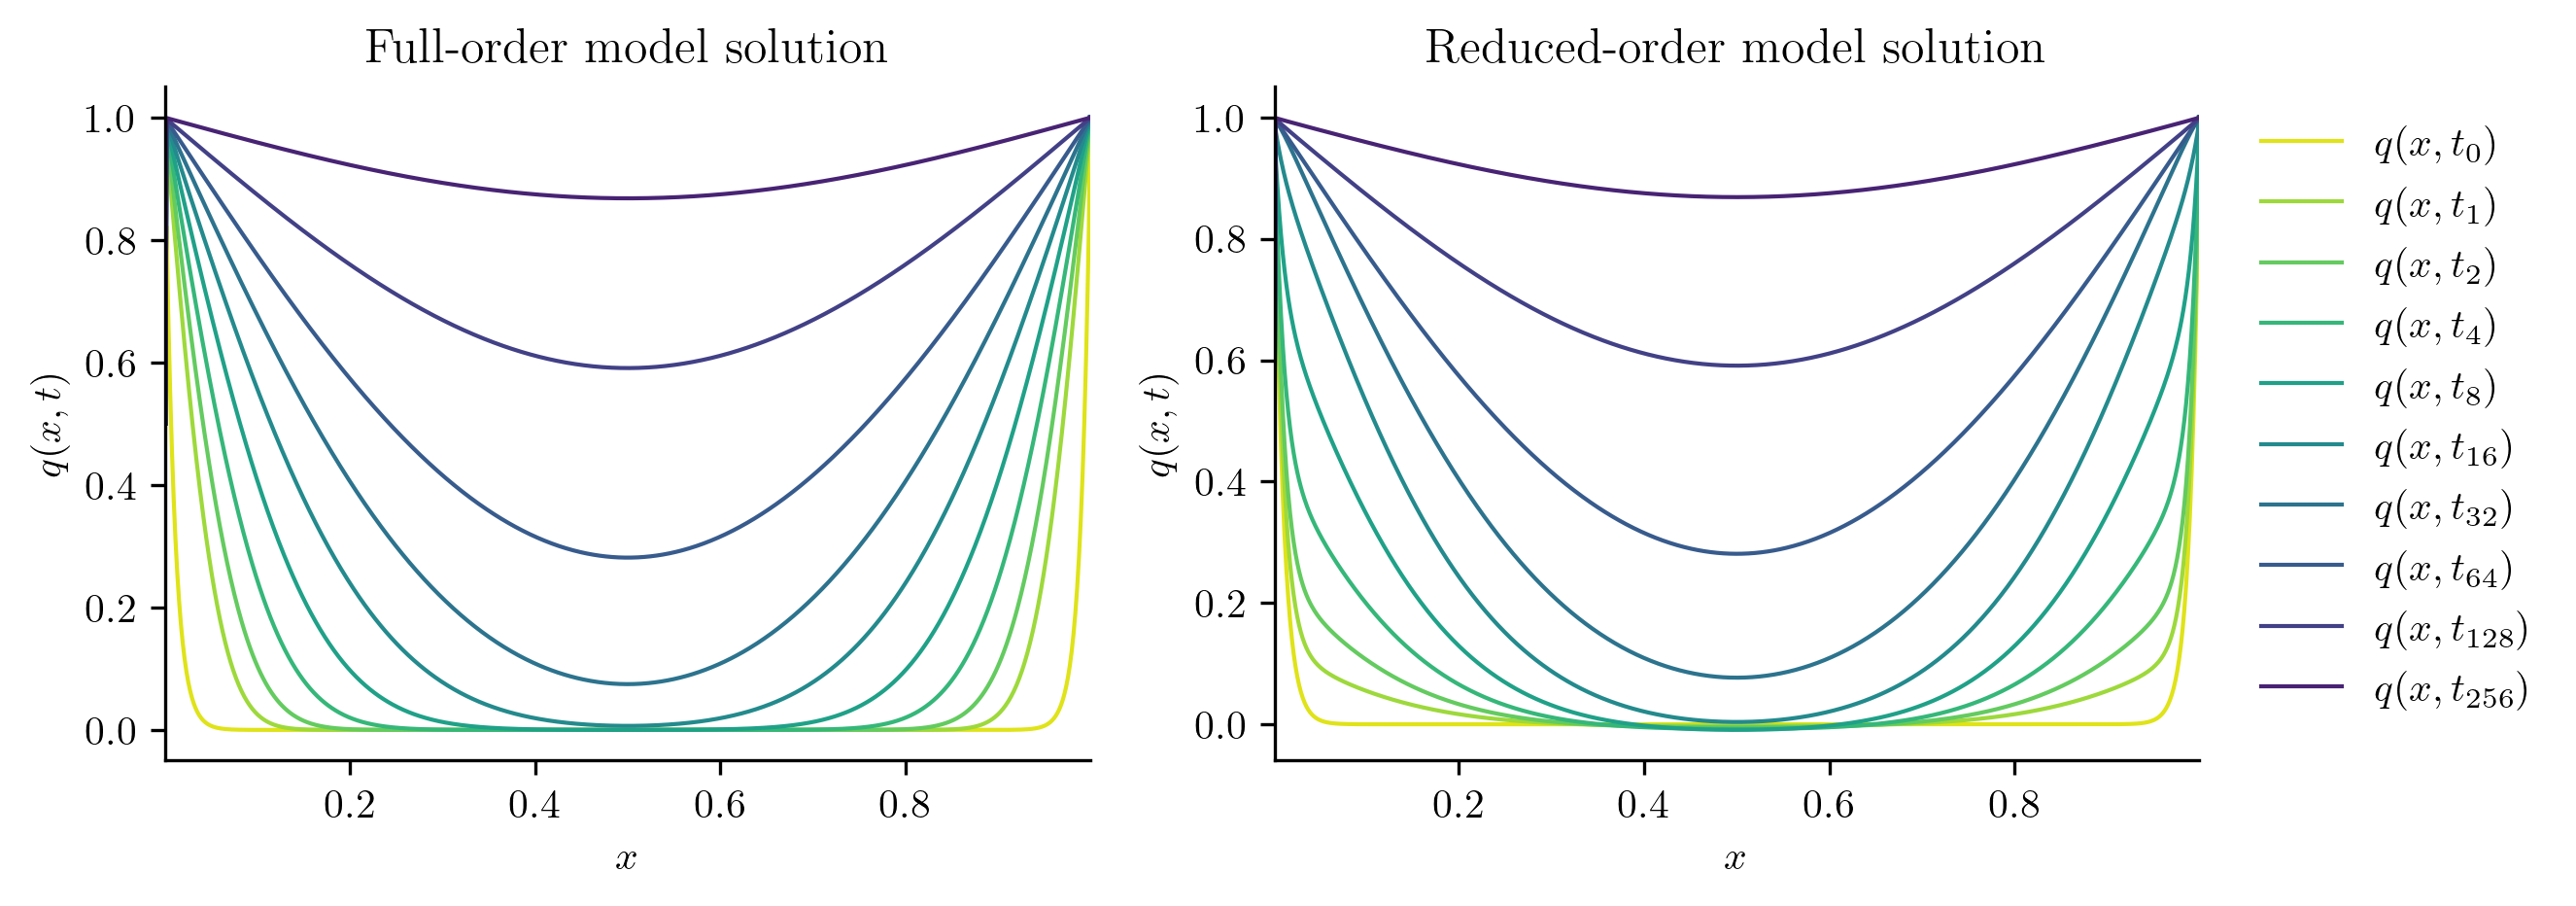

Reduced-order solve...done in 0.28 s.


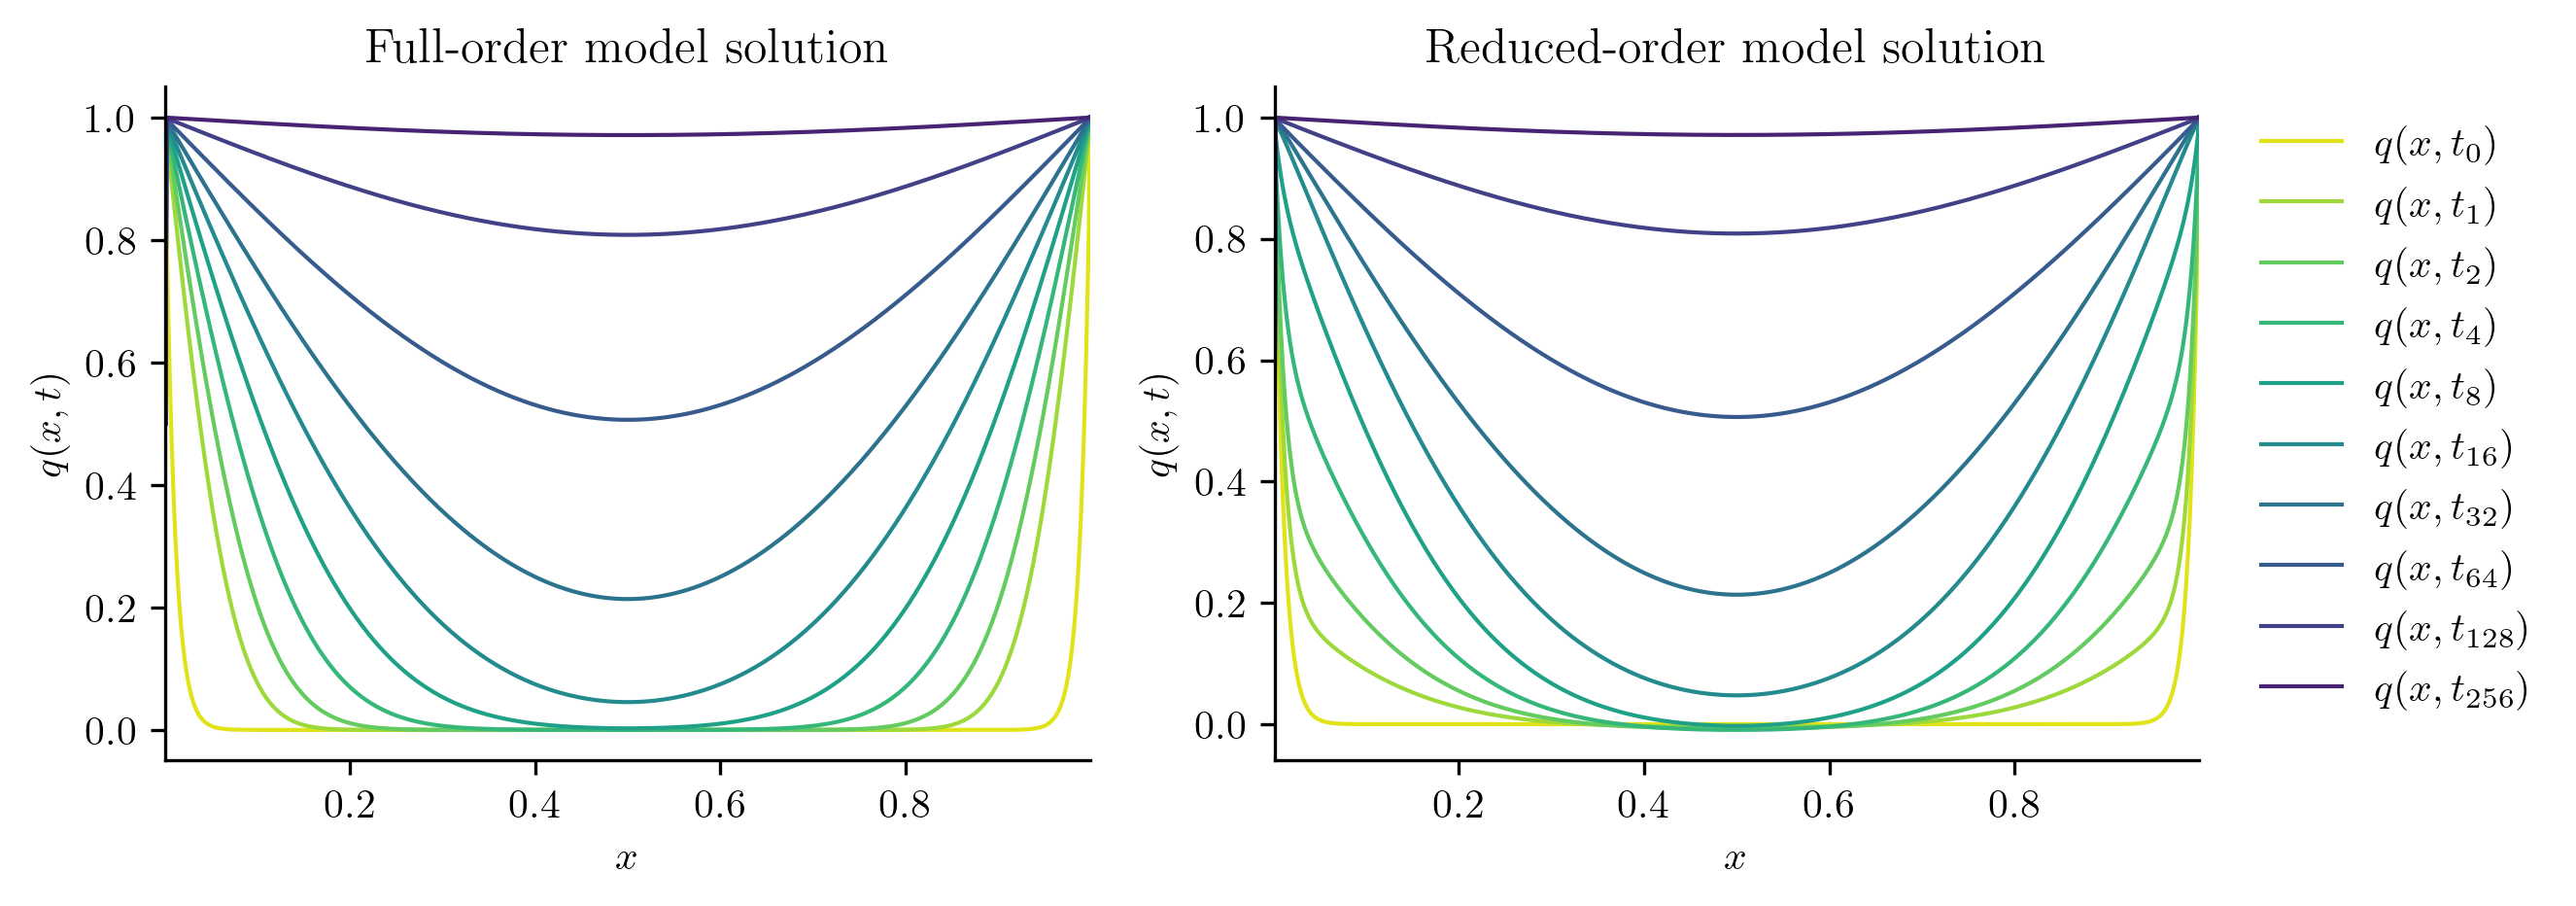

Reduced-order solve...done in 0.26 s.


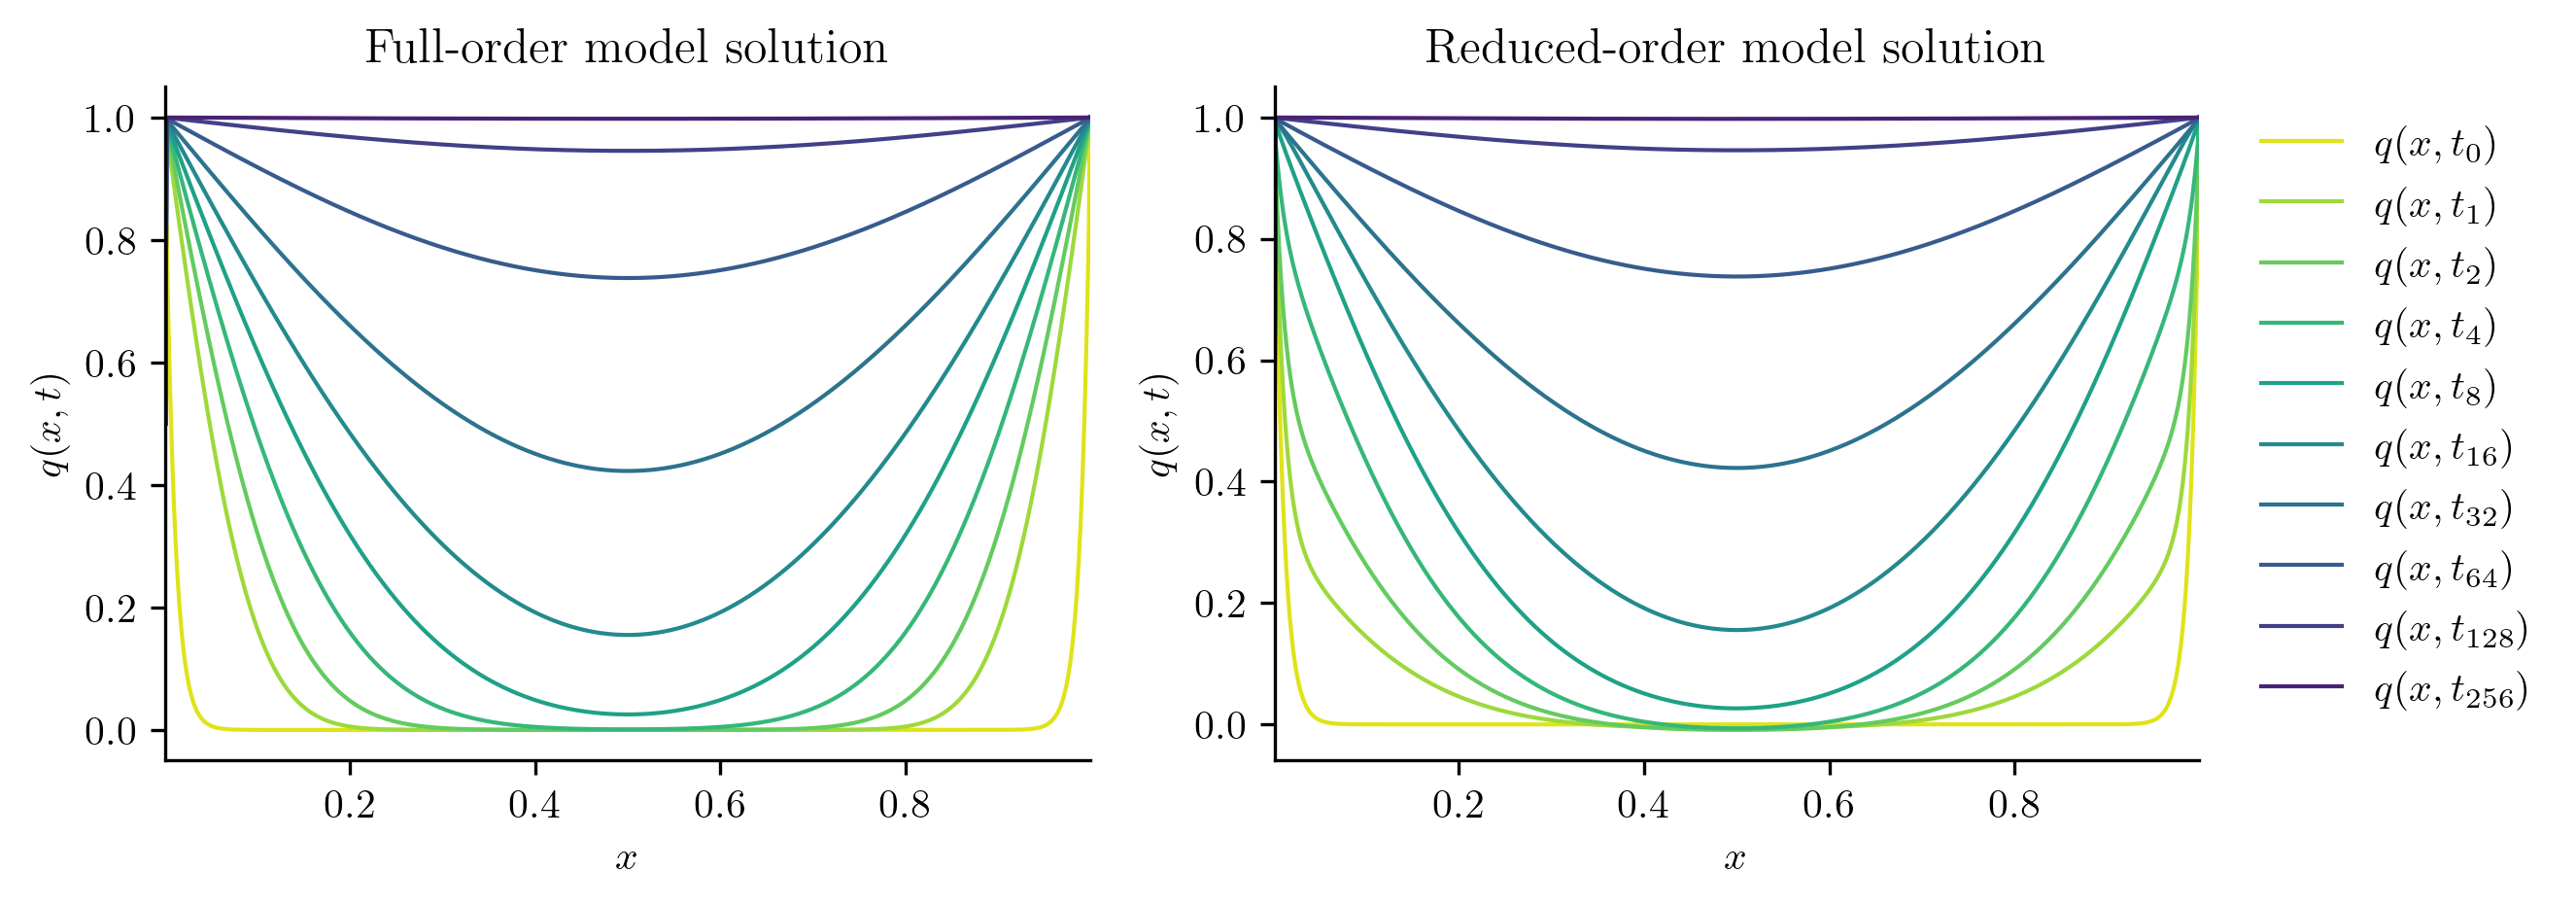

Reduced-order solve...done in 0.12 s.


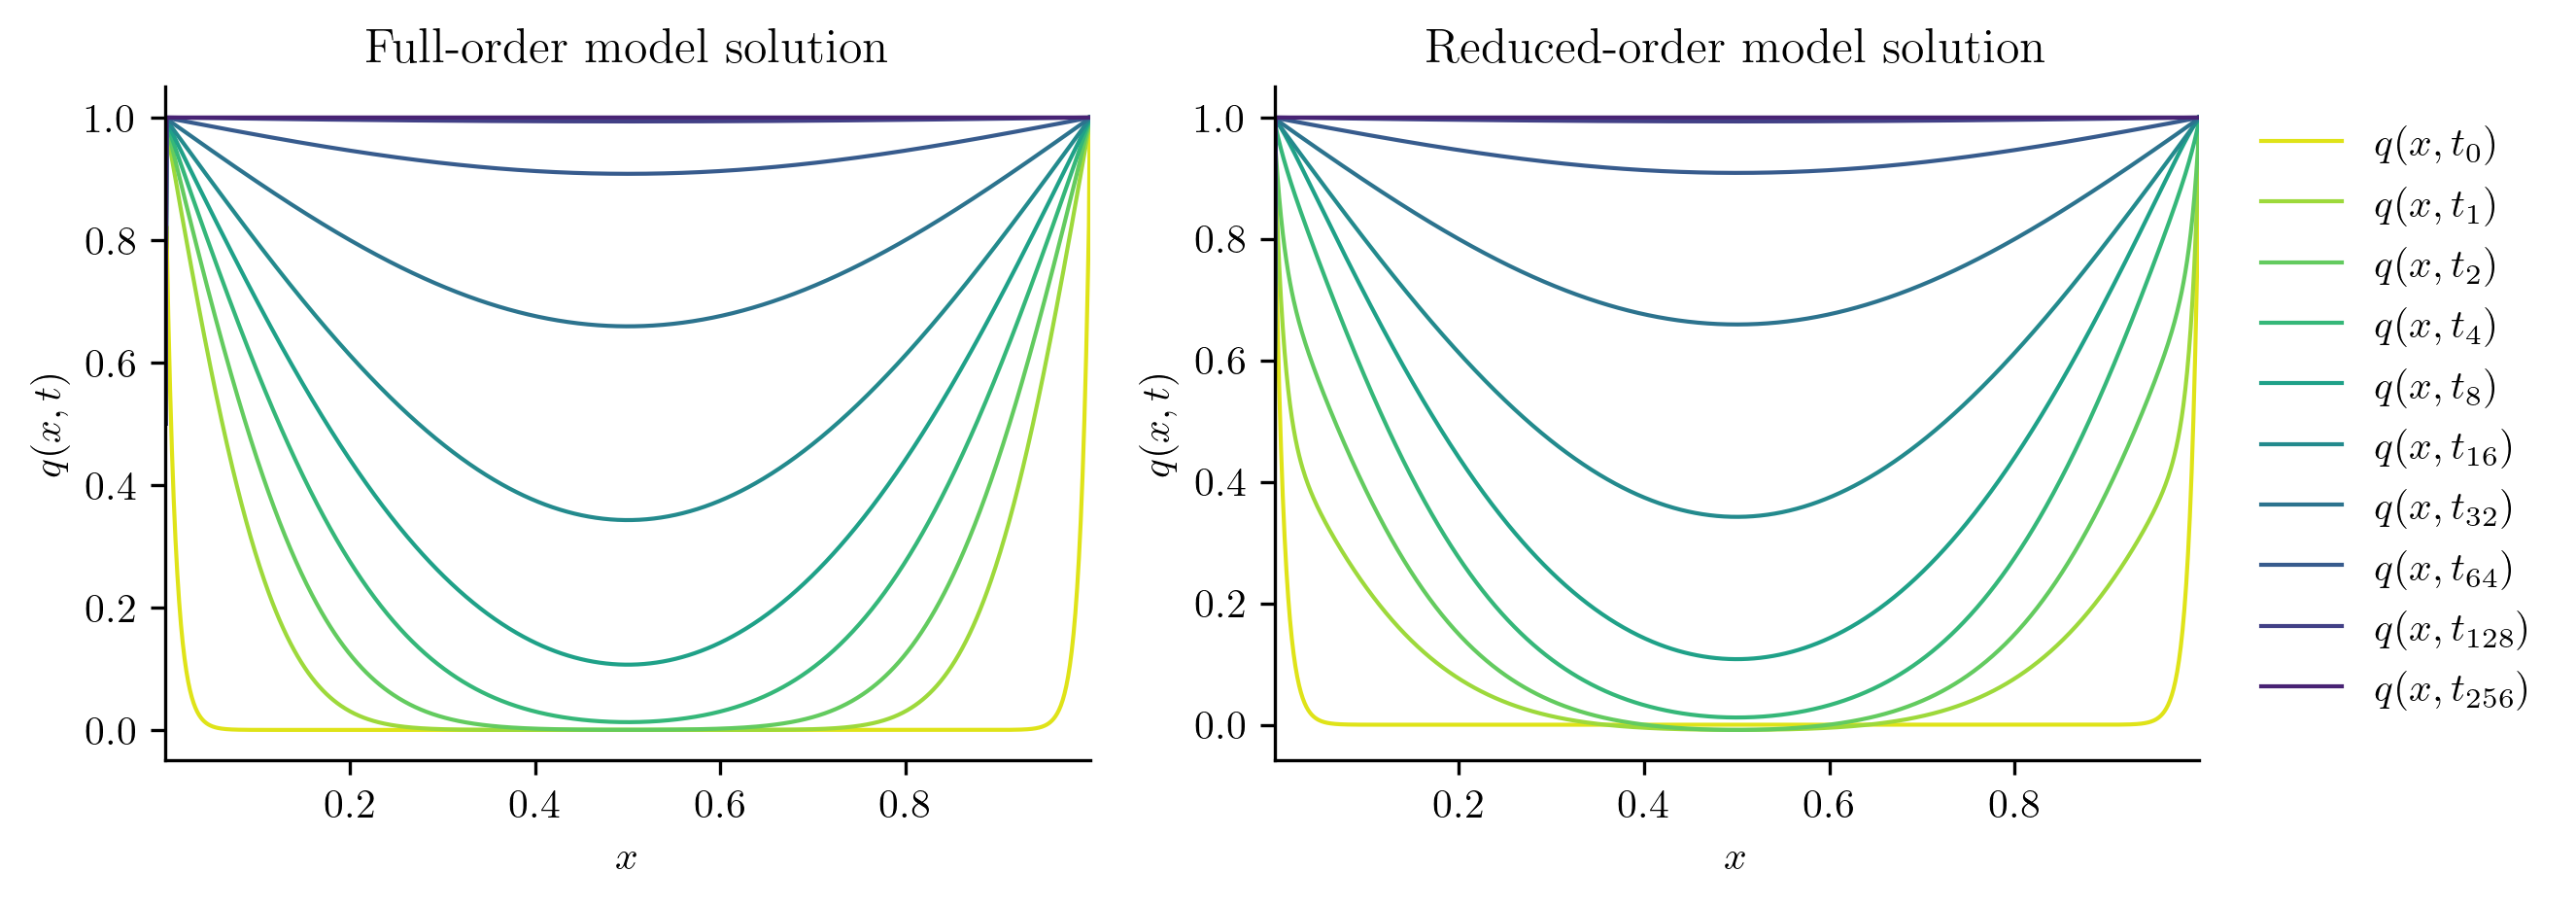

Reduced-order solve...done in 0.14 s.


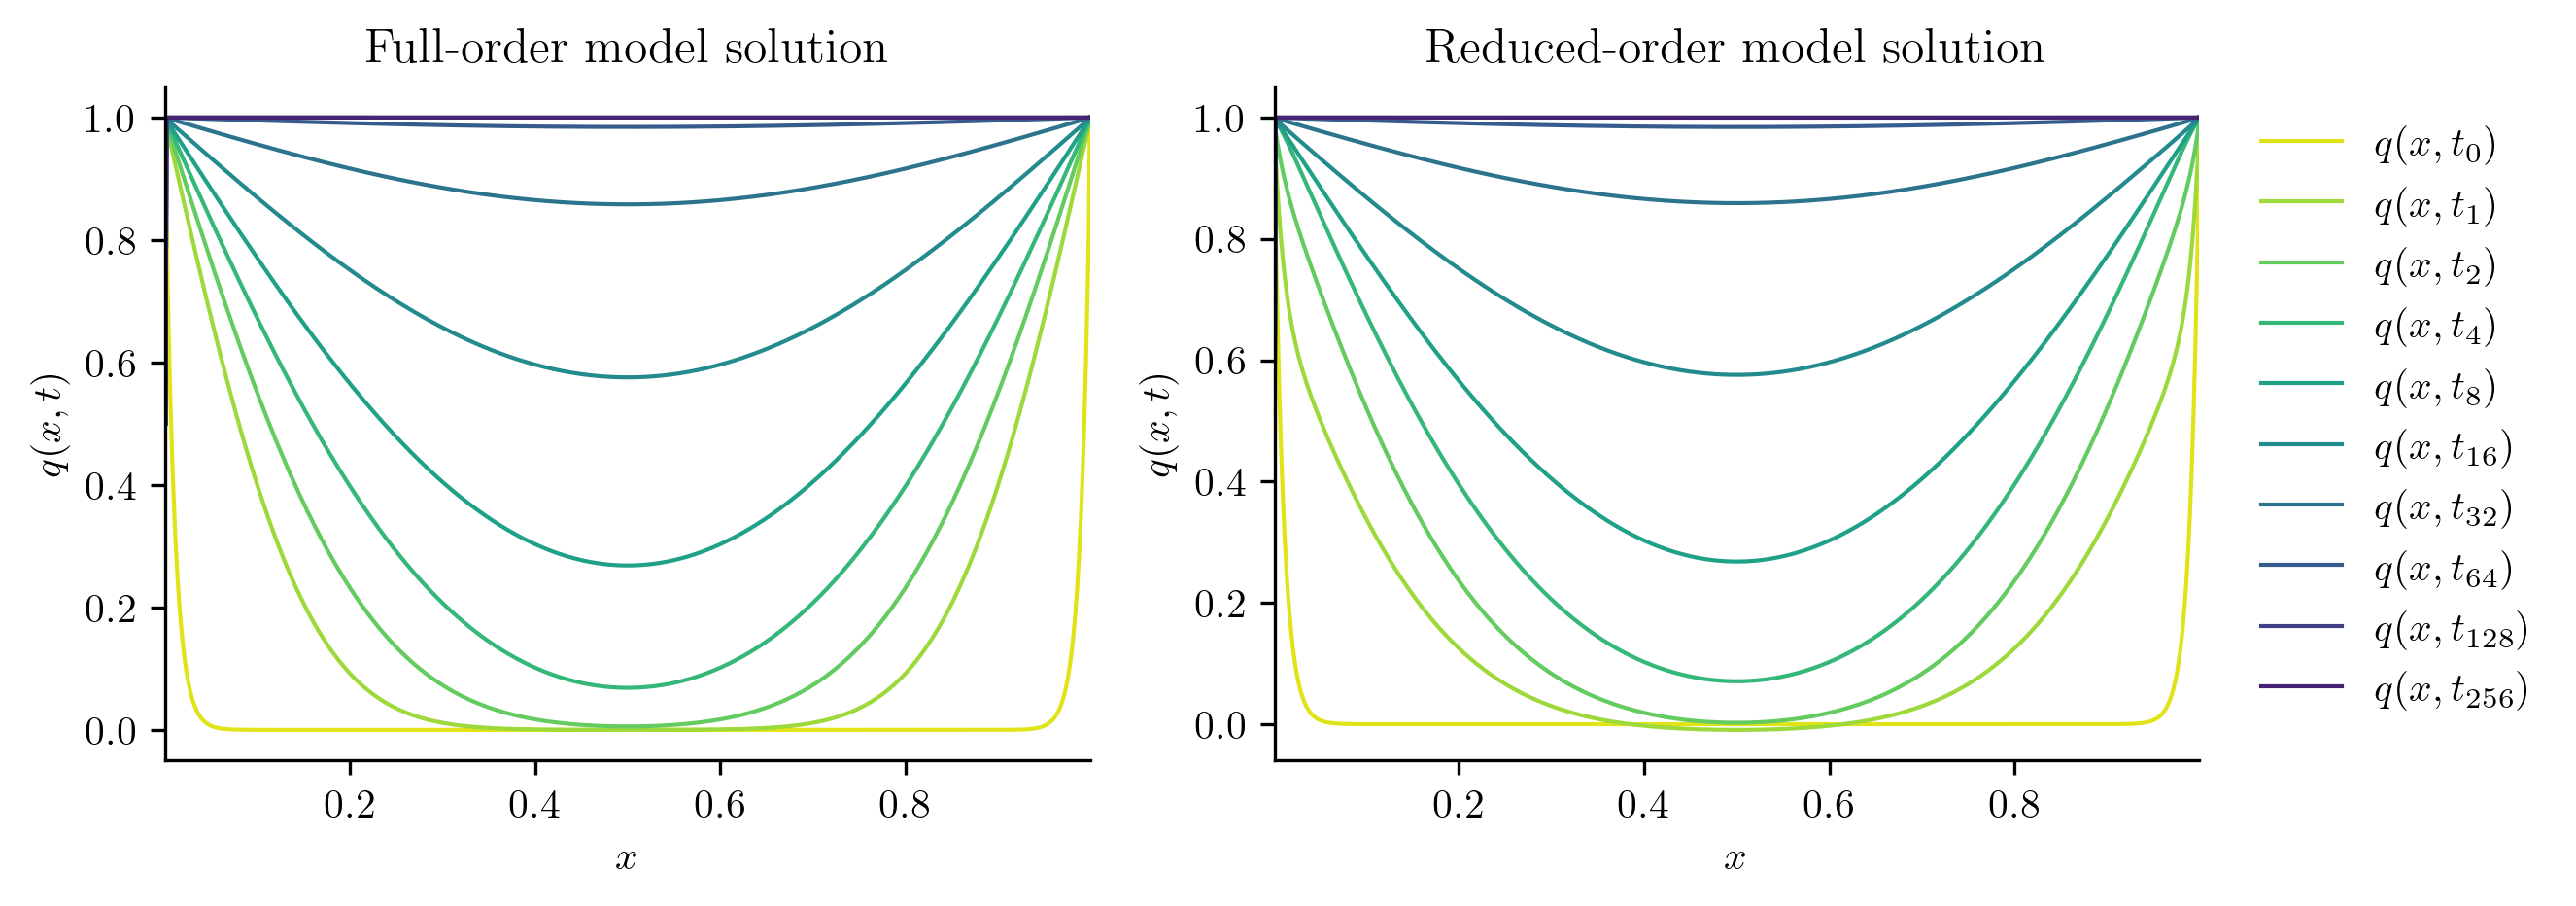

Reduced-order solve...done in 0.26 s.


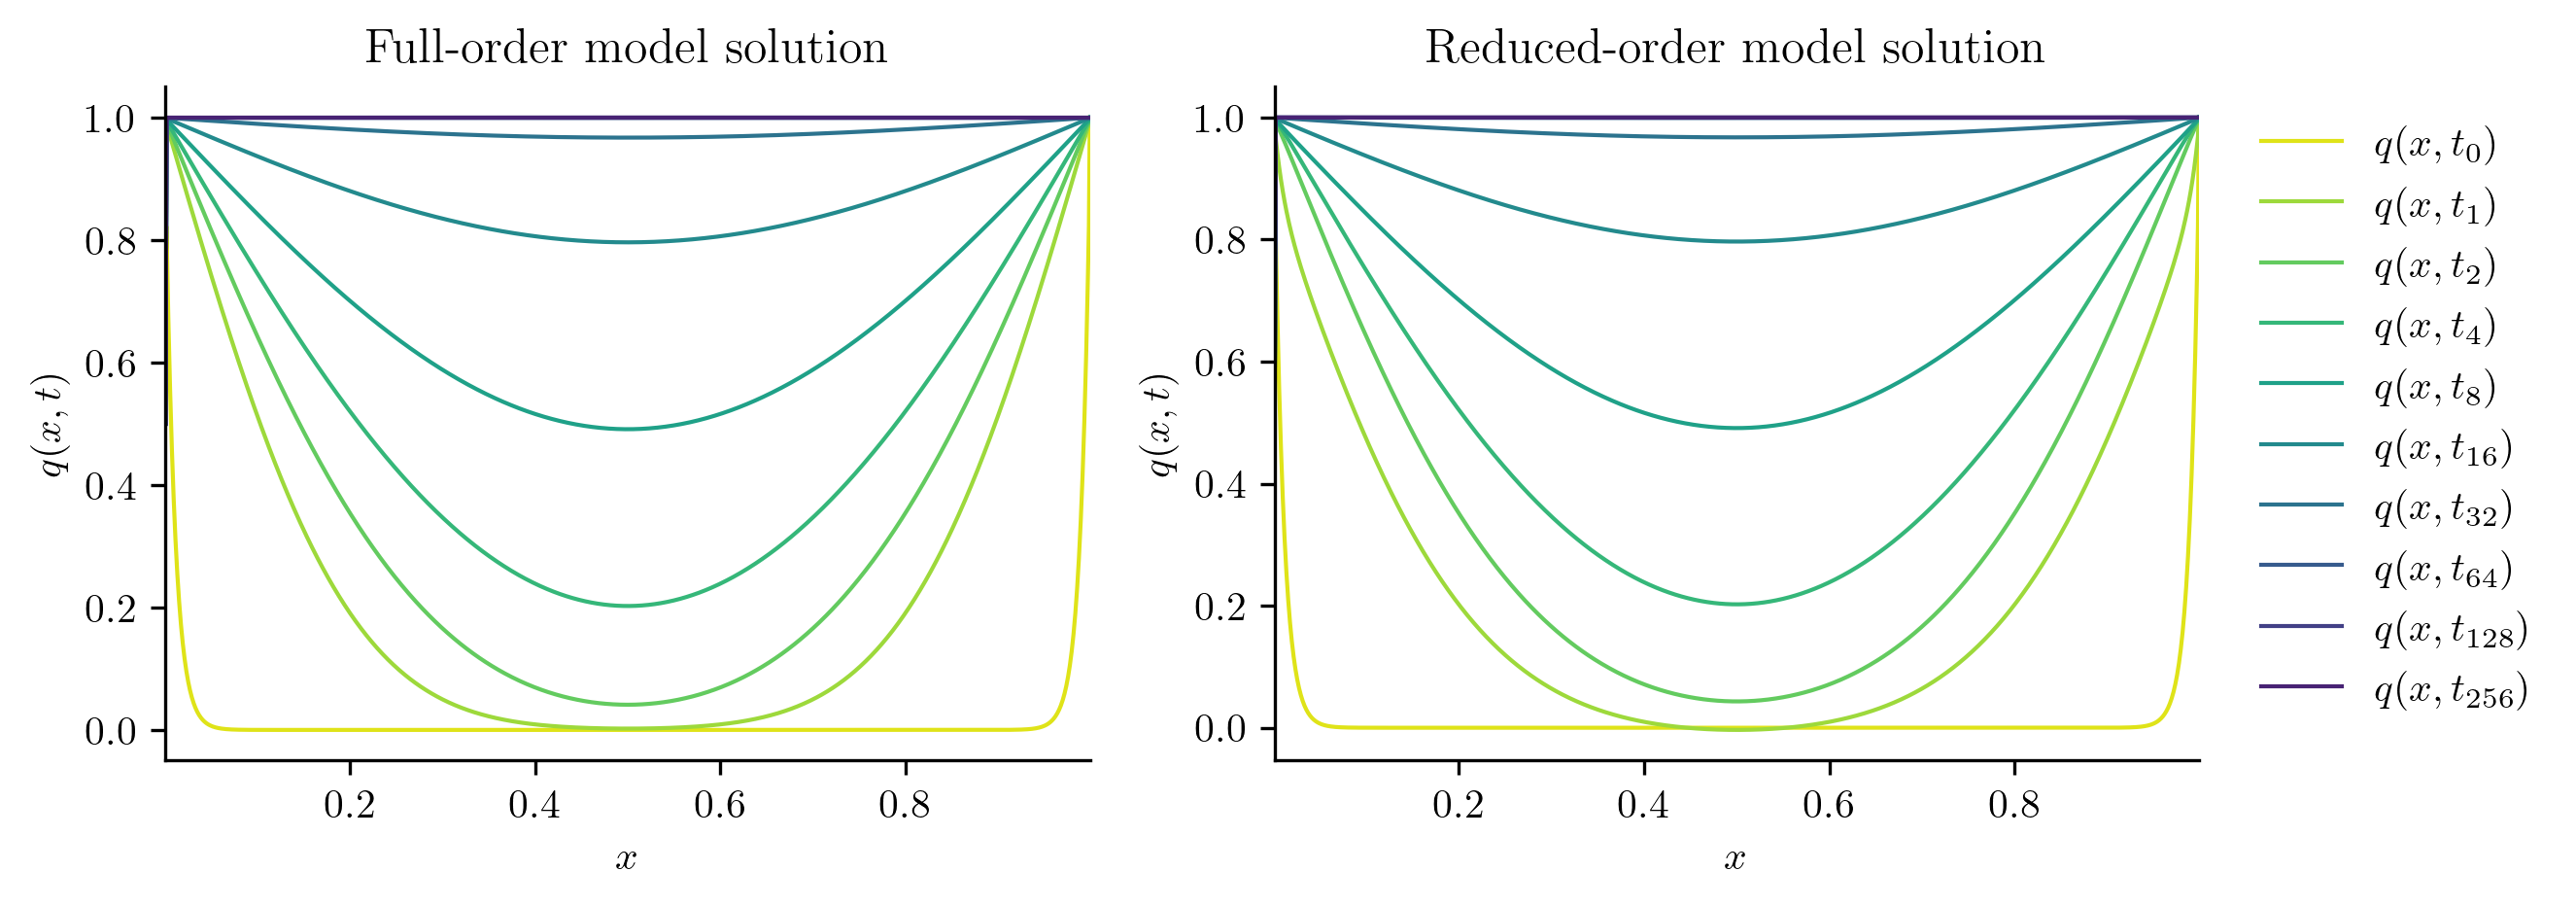

Reduced-order solve...done in 0.17 s.


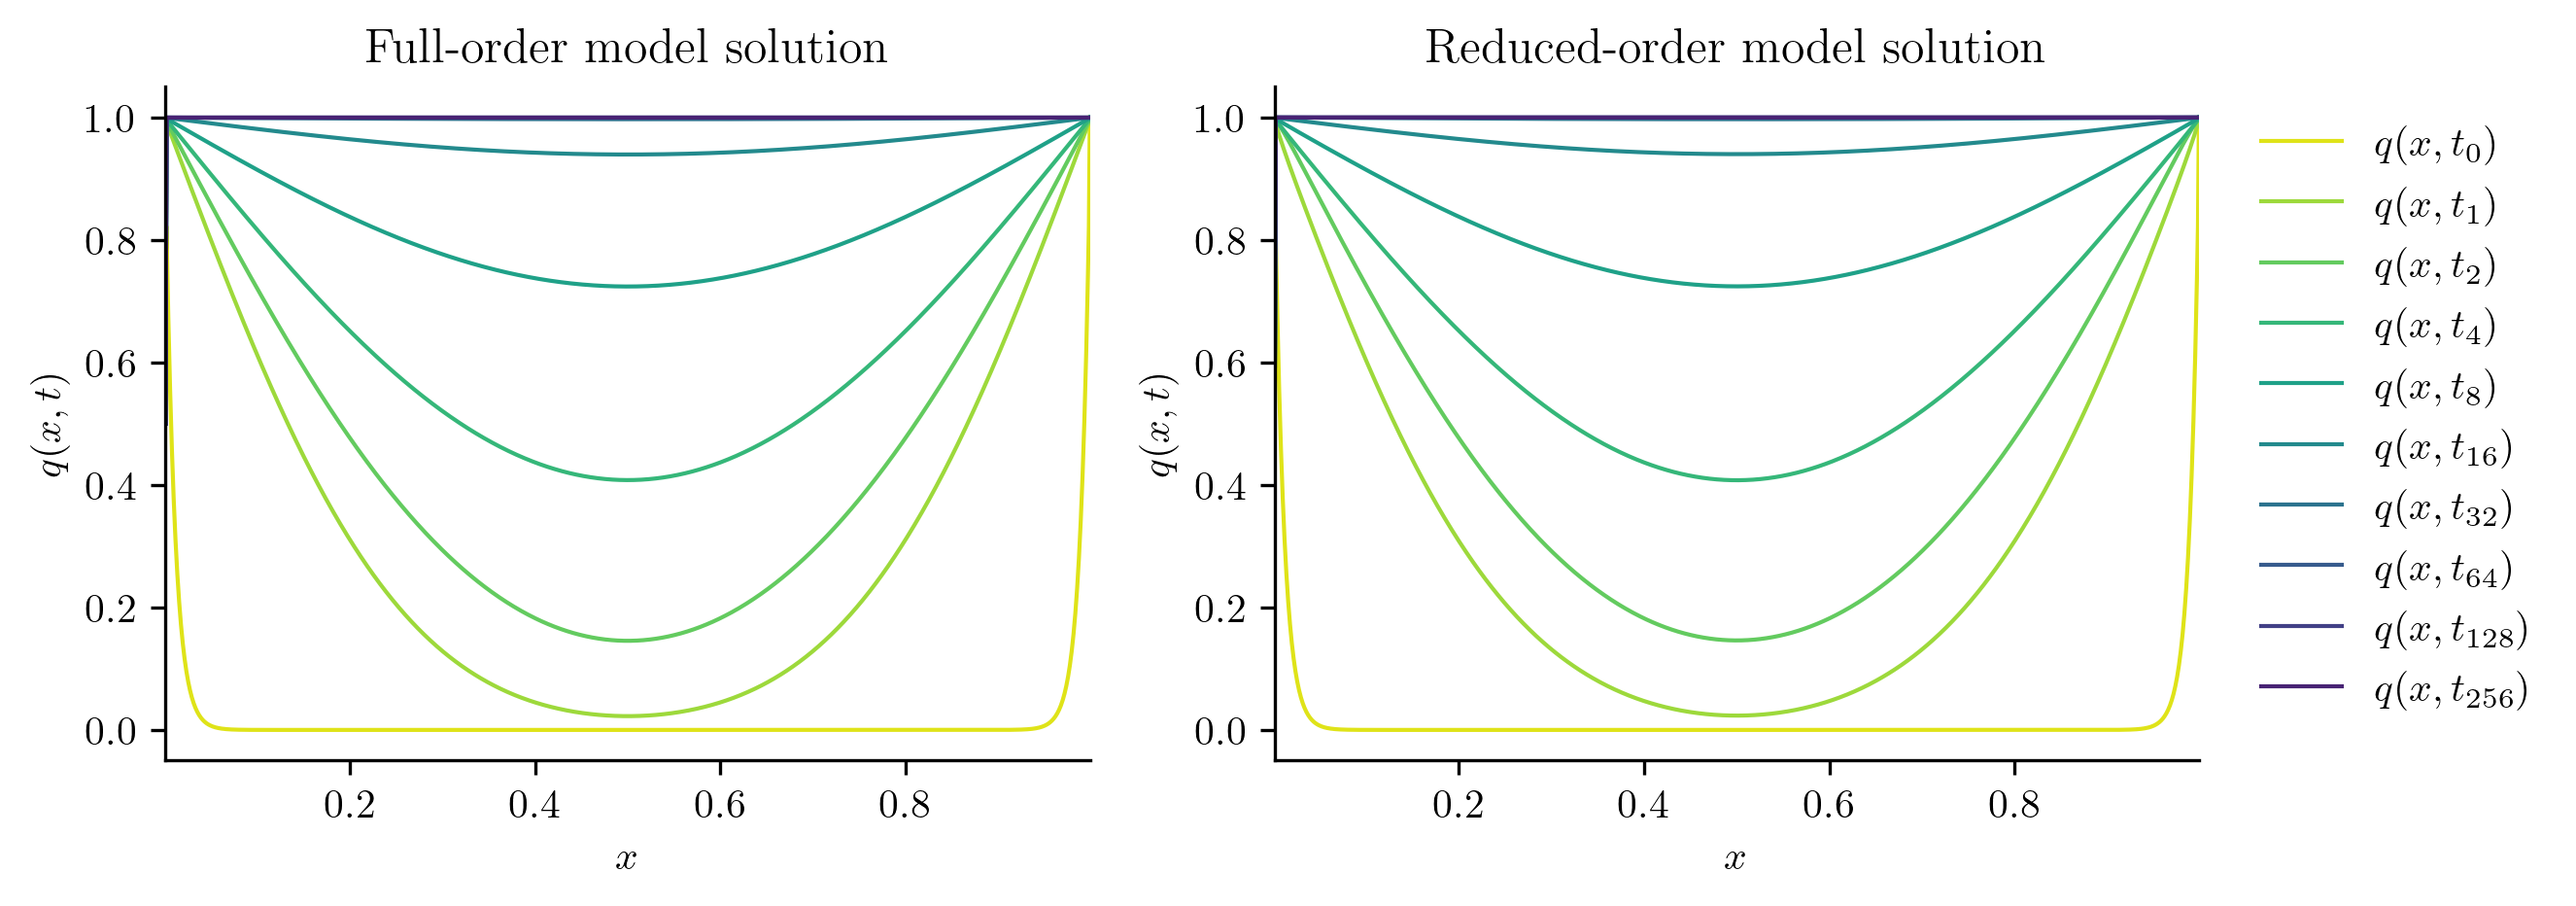

In [8]:
errors = []

for mu, Q_observed in zip(test_parameters, Qs_observed):

    with opinf.utils.TimedBlock("Reduced-order solve"):
        Q_ROM = rom.predict(mu, q0, t_all, method="BDF")

    plot_two_datasets(
        Q_observed,
        "Full-order model solution",
        Q_ROM,
        "Reduced-order model solution",
    )
    plt.show()
    errors.append(opinf.post.frobenius_error(Q_observed, Q_ROM)[1])

In [9]:
for mu, err in zip(test_parameters, errors):
    print(f"Test parameter mu = {mu:.6f}: error = {err:.4%}")

Test parameter mu = 0.129155: error = 4.2571%
Test parameter mu = 0.215443: error = 2.7810%
Test parameter mu = 0.359381: error = 1.8725%
Test parameter mu = 0.599484: error = 1.3092%
Test parameter mu = 1.000000: error = 0.9282%
Test parameter mu = 1.668101: error = 0.6361%
Test parameter mu = 2.782559: error = 0.3880%
Test parameter mu = 4.641589: error = 0.1760%
Test parameter mu = 7.742637: error = 0.0350%


:::{admonition} Stay Tuned
:class: note

More examples are forthcoming.
:::